# 과제 - PyTorch로 mini GPT 구현

이 노트북은 과제 안내서의 구현 순서를 그대로 따릅니다.

1. 환경설정
2. NSMC 데이터 준비
3. BPE 토크나이저
4. GPTDataset / InputEmbedding
5. MultiHeadAttention
6. GPTModel
7. 사전 학습 유틸리티
8. 감성 분류 미세 조정

각 단계의 `src/` TODO를 구현한 뒤, 바로 아래 pytest 셀로 해당 단계만 확인하세요.

## 1. 환경설정

Colab에서는 GitHub 저장소 URL과 GitHub Personal Access Token을 입력해 저장소를 clone하고 `src/`를 import 경로에 추가합니다.
로컬 VS Code에서는 현재 폴더를 프로젝트 루트로 보고 실행합니다.

In [1]:
# Colab: 이 셀을 가장 먼저 실행하세요.
import os
import subprocess
import sys
from pathlib import Path


def normalize_github_url(url: str) -> str:
    """Colab 입력값을 git clone에 사용할 수 있는 https URL로 정리합니다."""
    url = url.strip()
    if not url:
        raise ValueError("GitHub 저장소 URL을 입력해야 합니다.")
    if url.startswith("github.com/"):
        url = "https://" + url
    if not url.startswith("https://"):
        raise ValueError("저장소 URL은 https://github.com/... 또는 github.com/... 형식이어야 합니다.")
    url = url.rstrip("/")
    if not url.endswith(".git"):
        url += ".git"
    return url


if "google.colab" in sys.modules:
    from getpass import getpass

    repo_url = normalize_github_url(input("GitHub 저장소 URL (예: github.com/USERNAME/gpt-lab.git): "))
    token = getpass("GitHub Personal Access Token (Private 저장소인 경우 입력, 공개 저장소면 Enter): ").strip()
    clone_url = repo_url.replace("https://", f"https://{token}@") if token else repo_url
    repo_name = Path(repo_url[:-4]).name if repo_url.endswith(".git") else Path(repo_url).name
    repo_dir = Path("/content") / repo_name

    if not repo_dir.exists():
        subprocess.run(["git", "clone", clone_url, str(repo_dir)], check=True)
        subprocess.run(["git", "remote", "set-url", "origin", repo_url], cwd=repo_dir, check=True)
    else:
        print(f"이미 clone된 저장소를 사용합니다: {repo_dir}")

    os.chdir(repo_dir)
else:
    repo_dir = Path(".").resolve()

sys.path.insert(0, str(repo_dir / "src"))
print(f"Repo: {repo_dir}")

Repo: /home/yeong/llm/week13-14-team-04-gpt-lab


In [2]:
# 단계별 테스트 실행 helper
import subprocess
import sys


def run_pytest(target: str):
    cmd = [sys.executable, "-m", "pytest", target, "-v"]
    print("실행 명령:", " ".join(cmd))
    result = subprocess.run(cmd, cwd=str(repo_dir), text=True, capture_output=True)
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if result.returncode != 0:
        print("\n아직 통과하지 못한 테스트가 있습니다. 해당 단계의 TODO를 먼저 구현하세요.")
    else:
        print("\n선택한 테스트를 통과했습니다.")
    return result.returncode

## 2. NSMC 데이터 준비

기본 데이터는 NAVER Sentiment Movie Corpus(NSMC)입니다.
`download_data.py`는 원본 TSV를 내려받고, 사전 학습용 텍스트와 감성 분류용 JSONL을 만듭니다.

In [3]:
from pathlib import Path

try:
    import download_data

    paths = download_data.main()
except Exception as e:
    print("데이터 준비 중 문제가 생겼습니다:", e)
    print("이미 data/ 파일이 있다면 다음 셀부터 계속 진행할 수 있습니다.")

LM_TRAIN_PATH = repo_dir / "data" / "nsmc_lm_train.txt"
LM_VAL_PATH = repo_dir / "data" / "nsmc_lm_val.txt"
print("LM train exists:", LM_TRAIN_PATH.exists(), LM_TRAIN_PATH)
print("LM val exists:", LM_VAL_PATH.exists(), LM_VAL_PATH)

이미 존재합니다: /home/yeong/llm/week13-14-team-04-gpt-lab/data/ratings_train.txt
이미 존재합니다: /home/yeong/llm/week13-14-team-04-gpt-lab/data/ratings_test.txt
사전 학습 train 텍스트: /home/yeong/llm/week13-14-team-04-gpt-lab/data/nsmc_lm_train.txt (1,379,486자)
사전 학습 val 텍스트: /home/yeong/llm/week13-14-team-04-gpt-lab/data/nsmc_lm_val.txt (120,560자)
감성 분류 train: /home/yeong/llm/week13-14-team-04-gpt-lab/data/nsmc_sentiment_train.jsonl (137,996개)
감성 분류 val: /home/yeong/llm/week13-14-team-04-gpt-lab/data/nsmc_sentiment_val.jsonl (11,999개)
감성 분류 test: /home/yeong/llm/week13-14-team-04-gpt-lab/data/nsmc_sentiment_test.jsonl (49,997개)
LM train exists: True /home/yeong/llm/week13-14-team-04-gpt-lab/data/nsmc_lm_train.txt
LM val exists: True /home/yeong/llm/week13-14-team-04-gpt-lab/data/nsmc_lm_val.txt


In [4]:
corpus = LM_TRAIN_PATH.read_text(encoding="utf-8") if LM_TRAIN_PATH.exists() else ""
val_corpus = LM_VAL_PATH.read_text(encoding="utf-8") if LM_VAL_PATH.exists() else ""
print("train chars:", len(corpus))
print("val chars:", len(val_corpus))
print(corpus[:200])

train chars: 1379486
val chars: 120560
개재미없다. 감독의 연출력의 한계
이제서야 보게된 대 명작 연출미가 정말 훌륭하다!!!!!!!!
소주미라클을 만들어라
귀여운 캐릭터들도 많이 나와서 보러 가야 겠어요..
블랙 코미디가 싫어요.
평점깎고싶다10글자
TV시리즈가 너무재밌어서 영화는 기대안하고 봤는데 역시....최고네요
개인적 공감이 글쎄?
시작은 니시지마 때문에 봤는데 나름 괜찮은 영화 봤다고


## 3. Step 1 - BPE 토크나이저

구현 파일: `src/bpe.py`

먼저 `pytest tests/test_bpe.py -v`를 통과시키세요. 한국어를 안전하게 다루기 위해 UTF-8 byte-level BPE로 구현해야 합니다.

In [5]:
run_pytest("tests/test_bpe.py")

실행 명령: /home/yeong/anaconda3/envs/gpt-lab/bin/python -m pytest tests/test_bpe.py -v
============================= test session starts ==============================
platform linux -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /home/yeong/anaconda3/envs/gpt-lab/bin/python
cachedir: .pytest_cache
rootdir: /home/yeong/llm/week13-14-team-04-gpt-lab
plugins: anyio-4.13.0
collecting ... collected 6 items

tests/test_bpe.py::TestSpecialTokens::test_special_ids_fixed PASSED      [ 16%]
tests/test_bpe.py::TestBPETokenizer::test_init_special_tokens PASSED     [ 33%]
tests/test_bpe.py::TestBPETokenizer::test_save_load_restores_vocab PASSED [ 50%]
tests/test_bpe.py::TestBPETokenizer::test_encode_decode_restores_original_text PASSED [ 66%]
tests/test_bpe.py::TestBPETokenizer::test_get_special_ids PASSED         [ 83%]
tests/test_bpe.py::TestBPETrain::test_train_increases_vocab PASSED       [100%]

============================== 6 passed in 0.02s ===============================


선택한 테스트를 통과했습니다.

0

In [6]:
# BPE 구현 후 작은 말뭉치로 인코딩/디코딩 복원을 확인합니다.
try:
    from bpe import BPETokenizer

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    sample = "이 영화는 정말 좋았다! English 123"
    ids = tokenizer.encode(sample, add_bos_eos=True)
    print(ids[:20])
    print(tokenizer.decode(ids))
except NotImplementedError as e:
    print("BPE TODO 미구현:", e)

[2, 265, 260, 290, 268, 260, 164, 153, 274, 148, 260, 166, 143, 281, 156, 270, 37, 36, 73, 114]
이 영화는 정말 좋았다! English 123


## 4. Step 2 - GPTDataset / InputEmbedding

구현 파일: `src/dataset.py`, `src/embeddings.py`

BPE가 통과한 뒤 데이터셋과 입력 임베딩을 구현합니다.

In [7]:
run_pytest("tests/test_dataset.py")

실행 명령: /home/yeong/anaconda3/envs/gpt-lab/bin/python -m pytest tests/test_dataset.py -v
============================= test session starts ==============================
platform linux -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /home/yeong/anaconda3/envs/gpt-lab/bin/python
cachedir: .pytest_cache
rootdir: /home/yeong/llm/week13-14-team-04-gpt-lab
plugins: anyio-4.13.0
collecting ... collected 4 items

tests/test_dataset.py::TestGPTDataset::test_dataset_length PASSED        [ 25%]
tests/test_dataset.py::TestGPTDataset::test_dataset_getitem_shape PASSED [ 50%]
tests/test_dataset.py::TestCreateDataloader::test_dataloader_batch_shape PASSED [ 75%]
tests/test_dataset.py::TestInputEmbedding::test_input_embedding_shape PASSED [100%]

============================== 4 passed in 1.18s ===============================


선택한 테스트를 통과했습니다.


0

In [8]:
try:
    from bpe import BPETokenizer
    from dataset import create_dataloader
    from embeddings import InputEmbedding

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    token_ids = tokenizer.encode(corpus[:5000])
    loader = create_dataloader(token_ids, context_length=32, batch_size=2, shuffle=False)
    inp, tgt = next(iter(loader))
    emb = InputEmbedding(vocab_size=300, emb_dim=32, context_length=32, drop_rate=0.0)
    out = emb(inp)
    print(inp.shape, tgt.shape, out.shape)
except NotImplementedError as e:
    print("Dataset/Embedding TODO 미구현:", e)

torch.Size([2, 32]) torch.Size([2, 32]) torch.Size([2, 32, 32])


## 5. Step 3 - MultiHeadAttention

구현 파일: `src/attention.py`

Q/K/V shape, head 분리, causal mask를 차례로 확인하세요.

In [9]:
run_pytest("tests/test_attention.py")

실행 명령: /home/yeong/anaconda3/envs/gpt-lab/bin/python -m pytest tests/test_attention.py -v
============================= test session starts ==============================
platform linux -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /home/yeong/anaconda3/envs/gpt-lab/bin/python
cachedir: .pytest_cache
rootdir: /home/yeong/llm/week13-14-team-04-gpt-lab
plugins: anyio-4.13.0
collecting ... collected 2 items

tests/test_attention.py::TestMultiHeadAttention::test_mha_output_shape PASSED [ 50%]
tests/test_attention.py::TestMultiHeadAttention::test_mha_causal_mask_future_zero PASSED [100%]

============================== 2 passed in 0.90s ===============================


선택한 테스트를 통과했습니다.


0

## 6. Step 4 - GPTModel

구현 파일: `src/model.py`

LayerNorm, GELU, FeedForward, TransformerBlock, GPTModel, `generate_text_simple` 순서로 구현합니다.

In [10]:
run_pytest("tests/test_model.py")

실행 명령: /home/yeong/anaconda3/envs/gpt-lab/bin/python -m pytest tests/test_model.py -v
============================= test session starts ==============================
platform linux -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /home/yeong/anaconda3/envs/gpt-lab/bin/python
cachedir: .pytest_cache
rootdir: /home/yeong/llm/week13-14-team-04-gpt-lab
plugins: anyio-4.13.0
collecting ... collected 7 items

tests/test_model.py::TestLayerNorm::test_layernorm_shape PASSED          [ 14%]
tests/test_model.py::TestGELU::test_gelu_shape PASSED                    [ 28%]
tests/test_model.py::TestFeedForward::test_feedforward_shape PASSED      [ 42%]
tests/test_model.py::TestTransformerBlock::test_transformer_block_shape PASSED [ 57%]
tests/test_model.py::TestGPTModel::test_gpt_forward_shape PASSED         [ 71%]
tests/test_model.py::TestGPTModel::test_gpt_forward_with_targets_returns_loss PASSED [ 85%]
tests/test_model.py::TestGenerateTextSimple::test_generate_text_simple_shape PASSED [100%]

==

0

In [11]:
try:
    import torch
    from model import GPTModel

    config = {
        "vocab_size": 300,
        "context_length": 32,
        "emb_dim": 32,
        "n_heads": 4,
        "n_layers": 1,
        "drop_rate": 0.0,
        "qkv_bias": False,
    }
    config["vocab_size"] = len(tokenizer.id_to_token)

    model = GPTModel(config)
    x = torch.randint(0, config["vocab_size"], (2, 16))
    logits = model(x)
    print(logits.shape)
except NotImplementedError as e:
    print("Model TODO 미구현:", e)

torch.Size([2, 16, 300])


## 7. Step 5 - 사전 학습 유틸리티

구현 파일: `src/train.py`

loss 계산, checkpoint 저장/로드, temperature/top-k 생성, `train_model`을 구현합니다.

In [12]:
run_pytest("tests/test_train.py")

실행 명령: /home/yeong/anaconda3/envs/gpt-lab/bin/python -m pytest tests/test_train.py -v
============================= test session starts ==============================
platform linux -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /home/yeong/anaconda3/envs/gpt-lab/bin/python
cachedir: .pytest_cache
rootdir: /home/yeong/llm/week13-14-team-04-gpt-lab
plugins: anyio-4.13.0
collecting ... collected 5 items

tests/test_train.py::TestCalcLossBatch::test_calc_loss_batch_returns_scalar PASSED [ 20%]
tests/test_train.py::TestCalcLossLoader::test_calc_loss_loader_returns_float PASSED [ 40%]
tests/test_train.py::TestCheckpoint::test_save_load_checkpoint_restores_epoch_and_step PASSED [ 60%]
tests/test_train.py::TestGenerate::test_generate_shape PASSED            [ 80%]
tests/test_train.py::TestPlotLosses::test_plot_losses_callable PASSED    [100%]

============================== 5 passed in 1.93s ===============================


선택한 테스트를 통과했습니다.


0

In [13]:
# 모든 앞 단계가 구현된 뒤 한 배치 smoke test를 실행합니다.
try:
    import torch
    from bpe import BPETokenizer
    from dataset import create_dataloader
    from model import GPTModel
    from train import calc_loss_batch

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    token_ids = tokenizer.encode(corpus[:5000])
    loader = create_dataloader(token_ids, context_length=32, batch_size=2, shuffle=False)
    inp, tgt = next(iter(loader))
    config = {
        "vocab_size": 300,
        "context_length": 32,
        "emb_dim": 32,
        "n_heads": 4,
        "n_layers": 1,
        "drop_rate": 0.0,
        "qkv_bias": False,
    }
    model = GPTModel(config)
    loss = calc_loss_batch(inp, tgt, model, torch.device("cpu"))
    loss.backward()
    print("smoke loss:", loss.item())
except NotImplementedError as e:
    print("사전 학습 TODO 미구현:", e)

smoke loss: 5.8887152671813965


## 8. Step 6 - 감성 분류 미세 조정

구현 파일: `src/finetune.py`

NSMC JSONL/TSV를 읽어 분류 Dataset을 만들고, GPT backbone 위에 classification head를 붙입니다.

In [14]:
run_pytest("tests/test_finetune.py")

실행 명령: /home/yeong/anaconda3/envs/gpt-lab/bin/python -m pytest tests/test_finetune.py -v
============================= test session starts ==============================
platform linux -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /home/yeong/anaconda3/envs/gpt-lab/bin/python
cachedir: .pytest_cache
rootdir: /home/yeong/llm/week13-14-team-04-gpt-lab
plugins: anyio-4.13.0
collecting ... collected 4 items

tests/test_finetune.py::TestMakeSentimentDataset::test_make_sentiment_dataset_splits_rows PASSED [ 25%]
tests/test_finetune.py::TestReviewSentimentDataset::test_review_sentiment_dataset_getitem PASSED [ 50%]
tests/test_finetune.py::TestGPTForSequenceClassification::test_sequence_classification_shape PASSED [ 75%]
tests/test_finetune.py::TestSentimentTrainEval::test_train_eval_functions_exist PASSED [100%]

============================== 4 passed in 0.91s ===============================


선택한 테스트를 통과했습니다.


0

## 9. 전체 테스트와 제출 전 확인

각 단계 테스트가 모두 통과하면 마지막에 전체 테스트를 실행합니다.

In [15]:
run_pytest("tests/")

실행 명령: /home/yeong/anaconda3/envs/gpt-lab/bin/python -m pytest tests/ -v
============================= test session starts ==============================
platform linux -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /home/yeong/anaconda3/envs/gpt-lab/bin/python
cachedir: .pytest_cache
rootdir: /home/yeong/llm/week13-14-team-04-gpt-lab
plugins: anyio-4.13.0
collecting ... collected 28 items

tests/test_attention.py::TestMultiHeadAttention::test_mha_output_shape PASSED [  3%]
tests/test_attention.py::TestMultiHeadAttention::test_mha_causal_mask_future_zero PASSED [  7%]
tests/test_bpe.py::TestSpecialTokens::test_special_ids_fixed PASSED      [ 10%]
tests/test_bpe.py::TestBPETokenizer::test_init_special_tokens PASSED     [ 14%]
tests/test_bpe.py::TestBPETokenizer::test_save_load_restores_vocab PASSED [ 17%]
tests/test_bpe.py::TestBPETokenizer::test_encode_decode_restores_original_text PASSED [ 21%]
tests/test_bpe.py::TestBPETokenizer::test_get_special_ids PASSED         [ 25%]
tests/tes

0

In [ ]:
# NOTEBOOK_SAFE_GENERATION_PATCH
# 학습 초반 모델은 임의 byte 조합을 생성할 수 있으므로 UTF-8 디코딩을 안전하게 처리합니다.
import torch
import src.train as train_utils


def decode_token_ids_lossy(tokenizer, token_ids, skip_special=True):
    byte_parts = []
    for token_id in token_ids:
        token_id = int(token_id)
        token = tokenizer.id_to_token.get(token_id)
        if token is None:
            continue
        if isinstance(token, bytes):
            byte_parts.append(token)
        elif isinstance(token, tuple):
            byte_parts.append(tokenizer.decode_token(token_id, skip_special))
        elif isinstance(token, str):
            if not skip_special:
                byte_parts.append(token.encode("utf-8"))
    return b"".join(byte_parts).decode("utf-8", errors="replace")


def safe_generate_and_print_sample(
    model,
    tokenizer,
    device,
    start_context,
    max_new_tokens=50,
    context_size=None,
    temperature=0.8,
    top_k=40,
):
    model.eval()
    if context_size is None:
        context_size = model.config["context_length"]
    token_ids = tokenizer.encode(start_context)
    token = torch.tensor(token_ids, dtype=torch.long, device=device).unsqueeze(0)
    with torch.no_grad():
        token = train_utils.generate(
            model,
            token,
            max_new_tokens=max_new_tokens,
            context_size=context_size,
            temperature=temperature,
            top_k=top_k,
            eos_id=tokenizer.get_eos_id(),
        )
    print(decode_token_ids_lossy(tokenizer, token[0].tolist(), skip_special=True))
    model.train()


train_utils.generate_and_print_sample = safe_generate_and_print_sample


In [ ]:
from pathlib import Path

import torch

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import train_model, generate


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

corpus = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")[:10000]

tokenizer = BPETokenizer(vocab_size=500)
tokenizer.train(corpus)

ids = tokenizer.encode(corpus, add_bos_eos=False)
print("num tokens:", len(ids))

context_length = 32

train_loader = create_dataloader(
    ids,
    context_length=context_length,
    batch_size=4,
    shuffle=True,
)

config = {
    "vocab_size": len(tokenizer.id_to_token),
    "context_length": context_length,
    "emb_dim": 64,
    "n_heads": 4,
    "n_layers": 1,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

train_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=None,
    optimizer=optimizer,
    device=device,
    num_epochs=1,
    eval_freq=1,
    eval_iter=1,
    start_context="영화가",
    tokenizer=tokenizer,
    ckpt_freq=None,
)

print("train_losses:", train_losses)

start_ids = tokenizer.encode("영화가", add_bos_eos=False)
idx = torch.tensor(start_ids, dtype=torch.long, device=device).unsqueeze(0)

out = generate(
    model=model,
    idx=idx,
    max_new_tokens=20,
    context_size=context_length,
    temperature=1.0,
    top_k=20,
    eos_id=tokenizer.get_eos_id(),
)

print(decode_token_ids_lossy(tokenizer, out[0].tolist(), skip_special=True))

In [ ]:
from pathlib import Path

import torch

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import train_model, generate


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

corpus = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")[:100000]
val_corpus = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")[:20000]

tokenizer = BPETokenizer(vocab_size=1000)
tokenizer.train(corpus)

train_ids = tokenizer.encode(corpus, add_bos_eos=False)
val_ids = tokenizer.encode(val_corpus, add_bos_eos=False)

print("train tokens:", len(train_ids))
print("val tokens:", len(val_ids))

context_length = 64
batch_size = 16

train_loader = create_dataloader(
    train_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = create_dataloader(
    val_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=False,
)

config = {
    "vocab_size": len(tokenizer.id_to_token),
    "context_length": context_length,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

train_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=100,
    eval_freq=100,
    eval_iter=5,
    start_context="영화가",
    tokenizer=tokenizer,
    ckpt_freq=None,
)

print("train_losses:", train_losses)

for start_text in ["영화가", "정말", "배우가"]:
    start_ids = tokenizer.encode(start_text, add_bos_eos=False)
    idx = torch.tensor(start_ids, dtype=torch.long, device=device).unsqueeze(0)

    out = generate(
        model=model,
        idx=idx,
        max_new_tokens=40,
        context_size=context_length,
        temperature=0.8,
        top_k=40,
        eos_id=tokenizer.get_eos_id(),
    )

    print("=" * 40)
    print("prompt:", start_text)
    print(decode_token_ids_lossy(tokenizer, out[0].tolist(), skip_special=True))

In [ ]:
from pathlib import Path
import time

import torch

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import train_model, generate, calc_loss_loader, save_checkpoint


start_time = time.perf_counter()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

train_text = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
val_text = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

VOCAB_SIZE = 2000
TOKENIZER_PATH = Path(f"data/vocab_basic_{VOCAB_SIZE}.json")

tokenizer = BPETokenizer(vocab_size=VOCAB_SIZE)

if TOKENIZER_PATH.exists():
    print("load tokenizer:", TOKENIZER_PATH)
    tokenizer.load(TOKENIZER_PATH)
else:
    print("train tokenizer")
    tokenizer.train(train_text)
    tokenizer.save(TOKENIZER_PATH)
    print("saved tokenizer:", TOKENIZER_PATH)

print("encode train")
train_ids = tokenizer.encode(train_text, add_bos_eos=False)

print("encode val")
val_ids = tokenizer.encode(val_text, add_bos_eos=False)

print("train tokens:", len(train_ids))
print("val tokens:", len(val_ids))

context_length = 128
batch_size = 32

train_loader = create_dataloader(
    train_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

val_loader = create_dataloader(
    val_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

config = {
    "vocab_size": len(tokenizer.id_to_token),
    "context_length": context_length,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))

train_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=3,
    eval_freq=200,
    eval_iter=20,
    start_context="영화가",
    tokenizer=tokenizer,
    ckpt_freq=500,
)

final_val_loss = calc_loss_loader(
    val_loader,
    model,
    device,
    num_batches=50,
)

save_checkpoint(
    model=model,
    optimizer=optimizer,
    epoch=3,
    global_step=len(train_loader) * 3,
    path="checkpoints/basic_full_final.pt",
)

print("train_losses:", train_losses)
print("final_val_loss:", final_val_loss)

for start_text in ["영화가", "정말", "배우가", "스토리는"]:
    start_ids = tokenizer.encode(start_text, add_bos_eos=False)
    idx = torch.tensor(start_ids, dtype=torch.long, device=device).unsqueeze(0)

    out = generate(
        model=model,
        idx=idx,
        max_new_tokens=80,
        context_size=context_length,
        temperature=0.8,
        top_k=40,
        eos_id=tokenizer.get_eos_id(),
    )

    print("=" * 40)
    print("prompt:", start_text)
    print(decode_token_ids_lossy(tokenizer, out[0].tolist(), skip_special=True))

elapsed = time.perf_counter() - start_time
print(f"elapsed: {elapsed:.1f}s")

In [ ]:
from pathlib import Path
import time

import torch

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import train_model, generate, calc_loss_loader, save_checkpoint, load_checkpoint


start_time = time.perf_counter()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

train_text = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
val_text = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

tokenizer = BPETokenizer(vocab_size=2000)
tokenizer.load("data/vocab_basic_2000.json")

train_ids = tokenizer.encode(train_text, add_bos_eos=False)
val_ids = tokenizer.encode(val_text, add_bos_eos=False)

context_length = 128
batch_size = 32

train_loader = create_dataloader(
    train_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = create_dataloader(
    val_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=False,
)

config = {
    "vocab_size": len(tokenizer.id_to_token),
    "context_length": context_length,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

start_epoch, global_step = load_checkpoint(
    model=model,
    optimizer=optimizer,
    path="checkpoints/basic_full_final.pt",
    device=device,
)

print("resume epoch:", start_epoch)
print("resume global_step:", global_step)
print("train batches:", len(train_loader))

EXTRA_EPOCHS = 30

train_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=EXTRA_EPOCHS,
    eval_freq=500,
    eval_iter=20,
    start_context="영화가",
    tokenizer=tokenizer,
    ckpt_freq=1000,
    start_epoch=start_epoch,
    global_step=global_step,
)

final_global_step = global_step + len(train_loader) * EXTRA_EPOCHS
final_epoch = start_epoch + EXTRA_EPOCHS

final_val_loss = calc_loss_loader(
    val_loader,
    model,
    device,
    num_batches=50,
)

save_checkpoint(
    model=model,
    optimizer=optimizer,
    epoch=final_epoch,
    global_step=final_global_step,
    path=f"checkpoints/basic_full_epoch_{final_epoch}.pt",
)

print("continued train_losses:", train_losses)
print("final_val_loss:", final_val_loss)

for start_text in ["영화가", "정말", "배우가", "스토리는", "이 영화는"]:
    start_ids = tokenizer.encode(start_text, add_bos_eos=False)
    idx = torch.tensor(start_ids, dtype=torch.long, device=device).unsqueeze(0)

    out = generate(
        model=model,
        idx=idx,
        max_new_tokens=120,
        context_size=context_length,
        temperature=0.8,
        top_k=40,
        eos_id=tokenizer.get_eos_id(),
    )

    print("=" * 40)
    print("prompt:", start_text)
    print(decode_token_ids_lossy(tokenizer, out[0].tolist(), skip_special=True))

elapsed = time.perf_counter() - start_time
print(f"elapsed: {elapsed:.1f}s")
print("final_epoch:", final_epoch)
print("final_global_step:", final_global_step)

In [ ]:
from pathlib import Path
import gc
import json
import time

import matplotlib.pyplot as plt
import torch
from IPython.display import clear_output

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import calc_loss_batch, calc_loss_loader, save_checkpoint, load_checkpoint


for name in ["model", "optimizer", "loss", "logits", "input_batch", "target_batch"]:
    if name in globals():
        del globals()[name]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

tokenizer = BPETokenizer(vocab_size=2000)
tokenizer.load("data/vocab_basic_2000.json")

train_text = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
val_text = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

train_ids = tokenizer.encode(train_text, add_bos_eos=False)
val_ids = tokenizer.encode(val_text, add_bos_eos=False)

context_length = 128
batch_size = 32

train_loader = create_dataloader(
    train_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = create_dataloader(
    val_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=False,
)

config = {
    "vocab_size": len(tokenizer.id_to_token),
    "context_length": context_length,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

ckpt_dir = Path("checkpoints")
ckpt_dir.mkdir(parents=True, exist_ok=True)
latest_ckpt = ckpt_dir / "basic_monitor_latest.pt"
fallback_ckpt = ckpt_dir / "basic_full_epoch_33.pt"
ckpt_path = latest_ckpt if latest_ckpt.exists() else fallback_ckpt

start_epoch, global_step = load_checkpoint(
    model=model,
    optimizer=optimizer,
    path=str(ckpt_path),
    device=device,
)
print("loaded checkpoint:", ckpt_path)

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
}

EPOCHS_TO_RUN = 100
EVAL_BATCHES = 20
start_time = time.perf_counter()

for epoch in range(start_epoch, start_epoch + EPOCHS_TO_RUN):
    model.train()
    epoch_losses = []

    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())
        global_step += 1

    train_loss = sum(epoch_losses) / len(epoch_losses)
    model.eval()
    with torch.no_grad():
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=EVAL_BATCHES)
    val_loss = float(val_loss)

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    save_checkpoint(
        model=model,
        optimizer=optimizer,
        epoch=epoch + 1,
        global_step=global_step,
        path=str(latest_ckpt),
    )

    clear_output(wait=True)

    plt.figure(figsize=(8, 4))
    plt.plot(history["epoch"], history["train_loss"], label="train loss")
    plt.plot(history["epoch"], history["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Basic Pretraining Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    print("latest epoch:", epoch + 1)
    print("global_step:", global_step)
    print("train_loss:", train_loss)
    print("val_loss:", val_loss)
    print("elapsed:", round(time.perf_counter() - start_time, 1), "sec")

    Path("checkpoints/basic_monitor_history.json").write_text(
        json.dumps(history, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

In [ ]:
from pathlib import Path
import gc
import json
import time

import matplotlib.pyplot as plt
import torch
from IPython.display import clear_output

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import calc_loss_batch, calc_loss_loader, save_checkpoint, load_checkpoint


for name in ["model", "optimizer", "loss", "logits", "input_batch", "target_batch"]:
    if name in globals():
        del globals()[name]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

MAX_SECONDS = 60 * 60
EVAL_BATCHES = 20
PLOT_EVERY = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

tokenizer = BPETokenizer(vocab_size=2000)
tokenizer.load("data/vocab_basic_2000.json")

train_text = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
val_text = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

train_ids = tokenizer.encode(train_text, add_bos_eos=False)
val_ids = tokenizer.encode(val_text, add_bos_eos=False)

context_length = 128
batch_size = 32

train_loader = create_dataloader(
    train_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = create_dataloader(
    val_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=False,
)

config = {
    "vocab_size": len(tokenizer.id_to_token),
    "context_length": context_length,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

current_epoch, global_step = load_checkpoint(
    model=model,
    optimizer=optimizer,
    path="checkpoints/basic_monitor_latest.pt",
    device=device,
)

history_path = Path("checkpoints/basic_monitor_history.json")
history = json.loads(history_path.read_text(encoding="utf-8"))

best_val_loss = min(history["val_loss"])
print("start epoch:", current_epoch)
print("start global_step:", global_step)
print("best val loss:", best_val_loss)

start_time = time.perf_counter()

while time.perf_counter() - start_time < MAX_SECONDS:
    model.train()
    epoch_losses = []

    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())
        global_step += 1

    current_epoch += 1

    train_loss = sum(epoch_losses) / len(epoch_losses)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=EVAL_BATCHES)

    history["epoch"].append(current_epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    save_checkpoint(
        model=model,
        optimizer=optimizer,
        epoch=current_epoch,
        global_step=global_step,
        path="checkpoints/basic_monitor_latest.pt",
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(
            model=model,
            optimizer=optimizer,
            epoch=current_epoch,
            global_step=global_step,
            path="checkpoints/basic_monitor_best.pt",
        )

    history_path.write_text(
        json.dumps(history, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    if current_epoch % PLOT_EVERY == 0:
        clear_output(wait=True)

        plt.figure(figsize=(9, 4))
        plt.plot(history["epoch"], history["train_loss"], label="train loss")
        plt.plot(history["epoch"], history["val_loss"], label="val loss")
        plt.xlabel("epoch")
        plt.ylabel("loss")
        plt.title("Basic Pretraining Loss")
        plt.legend()
        plt.grid(True)
        plt.show()

        elapsed = time.perf_counter() - start_time
        print("latest epoch:", current_epoch)
        print("global_step:", global_step)
        print("train_loss:", train_loss)
        print("val_loss:", val_loss)
        print("best_val_loss:", best_val_loss)
        print("elapsed:", round(elapsed, 1), "sec")
        print("remaining:", round(MAX_SECONDS - elapsed, 1), "sec")

elapsed = time.perf_counter() - start_time

print("done")
print("final epoch:", current_epoch)
print("global_step:", global_step)
print("best_val_loss:", best_val_loss)
print("elapsed:", round(elapsed, 1), "sec")

In [ ]:
from pathlib import Path
import time
import json

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from src.bpe import BPETokenizer
from src.dataset import GPTDataset
from src.model import GPTModel
from src.train import calc_loss_batch, calc_loss_loader


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

tokenizer = BPETokenizer(vocab_size=2000)
tokenizer.load("data/vocab_basic_2000.json")

train_text = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
val_text = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

train_ids = tokenizer.encode(train_text, add_bos_eos=False)
val_ids = tokenizer.encode(val_text, add_bos_eos=False)

context_length = 128
batch_size = 32
epochs = 50
eval_batches = 20
seed = 123

config = {
    "vocab_size": len(tokenizer.id_to_token),
    "context_length": context_length,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

def make_activation(name):
    if name == "gelu":
        return nn.GELU()
    if name == "relu":
        return nn.ReLU()
    if name == "silu":
        return nn.SiLU()
    if name == "sigmoid":
        return nn.Sigmoid()
    raise ValueError(name)

def replace_activation(model, name):
    for block in model.blocks:
        block.ffn.net[1] = make_activation(name)

def make_loader(token_ids, shuffle, seed):
    dataset = GPTDataset(token_ids, context_length)
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator,
    )

results = {}

for activation_name in ["gelu", "relu", "silu", "sigmoid"]:
    print("=" * 50)
    print("activation:", activation_name)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    train_loader = make_loader(train_ids, shuffle=True, seed=seed)
    val_loader = make_loader(val_ids, shuffle=False, seed=seed)

    model = GPTModel(config).to(device)
    replace_activation(model, activation_name)

    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

    train_losses = []
    val_losses = []

    start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_losses = []

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        train_loss = sum(epoch_losses) / len(epoch_losses)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_batches)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"{activation_name} epoch {epoch:03d} "
            f"train {train_loss:.4f} val {val_loss:.4f}"
        )

    elapsed = time.perf_counter() - start

    results[activation_name] = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "elapsed": elapsed,
    }

    print("elapsed:", round(elapsed, 1), "sec")

Path("checkpoints/activation_ablation_results.json").write_text(
    json.dumps(results, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

plt.figure(figsize=(10, 5))
for name, result in results.items():
    plt.plot(result["val_loss"], label=name)

plt.xlabel("epoch")
plt.ylabel("val loss")
plt.title("Activation Function Ablation")
plt.legend()
plt.grid(True)
plt.show()

for name, result in results.items():
    print(
        name,
        "final val loss:",
        round(result["val_loss"][-1], 4),
        "best val loss:",
        round(min(result["val_loss"]), 4),
        "elapsed:",
        round(result["elapsed"], 1),
    )

In [ ]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from src.bpe import BPETokenizer
from src.dataset import GPTDataset
from src.model import GPTModel, FeedForward, GELU
from src.train import calc_loss_batch, calc_loss_loader


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

TRAIN_TEXT = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
VAL_TEXT = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

TOKENIZER_CACHE = {}
IDS_CACHE = {}

BASE_CONFIG = {
    "vocab_size": 2000,
    "context_length": 128,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

def get_tokenizer(vocab_size):
    if vocab_size in TOKENIZER_CACHE:
        return TOKENIZER_CACHE[vocab_size]

    path = Path(f"data/vocab_ablation_{vocab_size}.json")
    tokenizer = BPETokenizer(vocab_size=vocab_size)

    if path.exists():
        tokenizer.load(path)
    else:
        tokenizer.train(TRAIN_TEXT)
        tokenizer.save(path)

    TOKENIZER_CACHE[vocab_size] = tokenizer
    return tokenizer

def get_ids(vocab_size):
    if vocab_size in IDS_CACHE:
        return IDS_CACHE[vocab_size]

    tokenizer = get_tokenizer(vocab_size)
    train_ids = tokenizer.encode(TRAIN_TEXT, add_bos_eos=False)
    val_ids = tokenizer.encode(VAL_TEXT, add_bos_eos=False)
    IDS_CACHE[vocab_size] = (train_ids, val_ids)
    return train_ids, val_ids

def make_activation(name):
    if name == "gelu":
        return GELU()
    if name == "relu":
        return nn.ReLU()
    if name == "silu":
        return nn.SiLU()
    if name == "sigmoid":
        return nn.Sigmoid()
    raise ValueError(name)

def apply_overrides(model, config, overrides):
    activation = overrides.get("activation", "gelu")
    ffn_mult = overrides.get("ffn_mult", 4)

    for block in model.blocks:
        block.ffn = FeedForward(
            config["emb_dim"],
            dropout=config["drop_rate"],
            mult=ffn_mult,
        ).to(DEVICE)
        block.ffn.net[1] = make_activation(activation)

def make_loader(token_ids, context_length, batch_size, shuffle, seed):
    dataset = GPTDataset(token_ids, context_length)
    generator = torch.Generator()
    generator.manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator,
    )

def make_optimizer(model, overrides):
    lr = overrides.get("learning_rate", 3e-4)
    weight_decay = overrides.get("weight_decay", 0.0)
    opt_name = overrides.get("optimizer", "adamw")

    if opt_name == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    if opt_name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if opt_name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)

    raise ValueError(opt_name)

def run_one_experiment(name, overrides, epochs=30, seed=123, eval_batches=20):
    config = dict(BASE_CONFIG)
    config.update({k: v for k, v in overrides.items() if k in config})

    vocab_size = config["vocab_size"]
    context_length = config["context_length"]
    batch_size = overrides.get("batch_size", 32)

    train_ids, val_ids = get_ids(vocab_size)

    train_loader = make_loader(train_ids, context_length, batch_size, True, seed)
    val_loader = make_loader(val_ids, context_length, batch_size, False, seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = GPTModel(config).to(DEVICE)
    apply_overrides(model, config, overrides)
    optimizer = make_optimizer(model, overrides)

    train_losses = []
    val_losses = []
    start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_losses = []

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, DEVICE)
            loss.backward()

            if overrides.get("grad_clip") is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), overrides["grad_clip"])

            optimizer.step()
            epoch_losses.append(loss.item())

        train_loss = sum(epoch_losses) / len(epoch_losses)
        val_loss = calc_loss_loader(val_loader, model, DEVICE, num_batches=eval_batches)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"{name} epoch {epoch:03d} train {train_loss:.4f} val {val_loss:.4f}")

    return {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "elapsed": time.perf_counter() - start,
        "overrides": overrides,
    }

def run_ablation(category, variants, epochs=30):
    results = {}

    for name, overrides in variants:
        print("=" * 60)
        print(category, name)
        results[name] = run_one_experiment(
            name=f"{category}/{name}",
            overrides=overrides,
            epochs=epochs,
        )

    Path(f"checkpoints/ablation_{category}.json").write_text(
        json.dumps(results, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    plt.figure(figsize=(10, 5))
    for name, result in results.items():
        plt.plot(result["val_loss"], label=name)

    plt.xlabel("epoch")
    plt.ylabel("val loss")
    plt.title(f"{category} ablation")
    plt.legend()
    plt.grid(True)
    plt.show()

    for name, result in results.items():
        print(
            name,
            "final val:",
            round(result["val_loss"][-1], 4),
            "best val:",
            round(min(result["val_loss"]), 4),
            "elapsed:",
            round(result["elapsed"], 1),
        )

    return results

device: cuda


activation gelu
activation/gelu epoch 001 train 7.0561 val 6.9256
activation/gelu epoch 002 train 6.8731 val 6.7230
activation/gelu epoch 003 train 6.5174 val 6.1885
activation/gelu epoch 004 train 6.0586 val 5.8060
activation/gelu epoch 005 train 5.7780 val 5.5978
activation/gelu epoch 006 train 5.5989 val 5.4648
activation/gelu epoch 007 train 5.4760 val 5.3771
activation/gelu epoch 008 train 5.3857 val 5.3141
activation/gelu epoch 009 train 5.3168 val 5.2646
activation/gelu epoch 010 train 5.2615 val 5.2299
activation/gelu epoch 011 train 5.2155 val 5.1994
activation/gelu epoch 012 train 5.1785 val 5.1781
activation/gelu epoch 013 train 5.1459 val 5.1540
activation/gelu epoch 014 train 5.1170 val 5.1383
activation/gelu epoch 015 train 5.0919 val 5.1222
activation/gelu epoch 016 train 5.0686 val 5.1103
activation/gelu epoch 017 train 5.0488 val 5.0998
activation/gelu epoch 018 train 5.0306 val 5.0870
activation/gelu epoch 019 train 5.0122 val 5.0772
activation/gelu epoch 020 train 4.

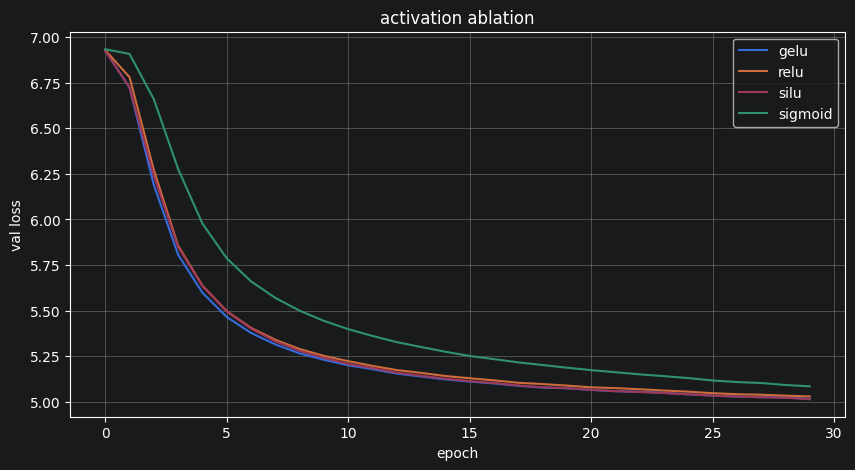

gelu final val: 5.0153 best val: 5.0153 elapsed: 82.7
relu final val: 5.0288 best val: 5.0288 elapsed: 77.4
silu final val: 5.0134 best val: 5.0134 elapsed: 74.8
sigmoid final val: 5.0842 best val: 5.0842 elapsed: 68.2


In [ ]:
activation_results = run_ablation(
    "activation",
    [
        ("gelu", {"activation": "gelu"}),
        ("relu", {"activation": "relu"}),
        ("silu", {"activation": "silu"}),
        ("sigmoid", {"activation": "sigmoid"}),
    ],
    epochs=30,
)

In [ ]:
# ABLATION_DROPOUT
dropout_results = run_ablation(
    "dropout",
    [
        ("drop_0_0", {"drop_rate": 0.0}),
        ("drop_0_1", {"drop_rate": 0.1}),
        ("drop_0_3", {"drop_rate": 0.3}),
    ],
    epochs=20,
)


device: cuda
dropout drop_0_0
dropout/drop_0_0 epoch 001 train 7.0448 val 6.9227
dropout/drop_0_0 epoch 002 train 6.8168 val 6.6119
dropout/drop_0_0 epoch 003 train 6.2761 val 5.9947
dropout/drop_0_0 epoch 004 train 5.7838 val 5.6724
dropout/drop_0_0 epoch 005 train 5.5181 val 5.4911
dropout/drop_0_0 epoch 006 train 5.3492 val 5.3745
dropout/drop_0_0 epoch 007 train 5.2328 val 5.3004
dropout/drop_0_0 epoch 008 train 5.1468 val 5.2493
dropout/drop_0_0 epoch 009 train 5.0802 val 5.2114
dropout/drop_0_0 epoch 010 train 5.0256 val 5.1828
dropout/drop_0_0 epoch 011 train 4.9793 val 5.1619
dropout/drop_0_0 epoch 012 train 4.9395 val 5.1485
dropout/drop_0_0 epoch 013 train 4.9036 val 5.1339
dropout/drop_0_0 epoch 014 train 4.8711 val 5.1263
dropout/drop_0_0 epoch 015 train 4.8417 val 5.1184
dropout/drop_0_0 epoch 016 train 4.8141 val 5.1163
dropout/drop_0_0 epoch 017 train 4.7879 val 5.1130
dropout/drop_0_0 epoch 018 train 4.7635 val 5.1130
dropout/drop_0_0 epoch 019 train 4.7409 val 5.1094
d

In [ ]:
# ABLATION_LEARNING_RATE
learning_rate_results = run_ablation(
    "learning_rate",
    [
        ("lr_1e_4", {"learning_rate": 1e-4}),
        ("lr_3e_4", {"learning_rate": 3e-4}),
        ("lr_1e_3", {"learning_rate": 1e-3}),
    ],
    epochs=20,
)


### RUN ABLATION_LEARNING_RATE
learning_rate lr_1e_4
learning_rate/lr_1e_4 epoch 001 train 7.2475 val 6.9452
learning_rate/lr_1e_4 epoch 002 train 6.9418 val 6.9307
learning_rate/lr_1e_4 epoch 003 train 6.9315 val 6.9209
learning_rate/lr_1e_4 epoch 004 train 6.9140 val 6.8904
learning_rate/lr_1e_4 epoch 005 train 6.8604 val 6.7993
learning_rate/lr_1e_4 epoch 006 train 6.7532 val 6.6589
learning_rate/lr_1e_4 epoch 007 train 6.6117 val 6.4895
learning_rate/lr_1e_4 epoch 008 train 6.4511 val 6.3075
learning_rate/lr_1e_4 epoch 009 train 6.2904 val 6.1421
learning_rate/lr_1e_4 epoch 010 train 6.1480 val 6.0056
learning_rate/lr_1e_4 epoch 011 train 6.0317 val 5.9002
learning_rate/lr_1e_4 epoch 012 train 5.9351 val 5.8139
learning_rate/lr_1e_4 epoch 013 train 5.8531 val 5.7377
learning_rate/lr_1e_4 epoch 014 train 5.7827 val 5.6742
learning_rate/lr_1e_4 epoch 015 train 5.7193 val 5.6194
learning_rate/lr_1e_4 epoch 016 train 5.6644 val 5.5715
learning_rate/lr_1e_4 epoch 017 train 5.6160 val 5.

In [ ]:
# ABLATION_OPTIMIZER_WEIGHT_DECAY
optimizer_weight_decay_results = run_ablation(
    "optimizer_weight_decay",
    [
        ("adamw_wd_0", {"optimizer": "adamw", "weight_decay": 0.0}),
        ("adamw_wd_0_01", {"optimizer": "adamw", "weight_decay": 0.01}),
        ("adam_wd_0", {"optimizer": "adam", "weight_decay": 0.0}),
        ("sgd_lr_1e_2", {"optimizer": "sgd", "learning_rate": 1e-2}),
    ],
    epochs=20,
)


### RUN ABLATION_OPTIMIZER_WEIGHT_DECAY
optimizer_weight_decay adamw_wd_0
optimizer_weight_decay/adamw_wd_0 epoch 001 train 7.0561 val 6.9256
optimizer_weight_decay/adamw_wd_0 epoch 002 train 6.8731 val 6.7230
optimizer_weight_decay/adamw_wd_0 epoch 003 train 6.5174 val 6.1885
optimizer_weight_decay/adamw_wd_0 epoch 004 train 6.0586 val 5.8060
optimizer_weight_decay/adamw_wd_0 epoch 005 train 5.7780 val 5.5978
optimizer_weight_decay/adamw_wd_0 epoch 006 train 5.5989 val 5.4648
optimizer_weight_decay/adamw_wd_0 epoch 007 train 5.4760 val 5.3771
optimizer_weight_decay/adamw_wd_0 epoch 008 train 5.3857 val 5.3141
optimizer_weight_decay/adamw_wd_0 epoch 009 train 5.3168 val 5.2646
optimizer_weight_decay/adamw_wd_0 epoch 010 train 5.2615 val 5.2299
optimizer_weight_decay/adamw_wd_0 epoch 011 train 5.2155 val 5.1994
optimizer_weight_decay/adamw_wd_0 epoch 012 train 5.1785 val 5.1781
optimizer_weight_decay/adamw_wd_0 epoch 013 train 5.1459 val 5.1540
optimizer_weight_decay/adamw_wd_0 epoch 01

In [ ]:
# ABLATION_CONTEXT_LENGTH
context_length_results = run_ablation(
    "context_length",
    [
        ("ctx_64", {"context_length": 64}),
        ("ctx_128", {"context_length": 128}),
        ("ctx_256", {"context_length": 256}),
    ],
    epochs=20,
)


### RUN ABLATION_CONTEXT_LENGTH
context_length ctx_64
context_length/ctx_64 epoch 001 train 6.9993 val 6.8667
context_length/ctx_64 epoch 002 train 6.5588 val 6.0892
context_length/ctx_64 epoch 003 train 5.9225 val 5.6383
context_length/ctx_64 epoch 004 train 5.6029 val 5.4321
context_length/ctx_64 epoch 005 train 5.4284 val 5.3151
context_length/ctx_64 epoch 006 train 5.3178 val 5.2384
context_length/ctx_64 epoch 007 train 5.2390 val 5.1873
context_length/ctx_64 epoch 008 train 5.1790 val 5.1495
context_length/ctx_64 epoch 009 train 5.1322 val 5.1214
context_length/ctx_64 epoch 010 train 5.0933 val 5.0976
context_length/ctx_64 epoch 011 train 5.0599 val 5.0749
context_length/ctx_64 epoch 012 train 5.0300 val 5.0608
context_length/ctx_64 epoch 013 train 5.0033 val 5.0437
context_length/ctx_64 epoch 014 train 4.9794 val 5.0291
context_length/ctx_64 epoch 015 train 4.9569 val 5.0111
context_length/ctx_64 epoch 016 train 4.9364 val 4.9992
context_length/ctx_64 epoch 017 train 4.9159 val 4

In [ ]:
# ABLATION_VOCAB_SIZE
vocab_size_results = run_ablation(
    "vocab_size",
    [
        ("vocab_1000", {"vocab_size": 1000}),
        ("vocab_2000", {"vocab_size": 2000}),
        ("vocab_4000", {"vocab_size": 4000}),
    ],
    epochs=10,
)


### RUN ABLATION_VOCAB_SIZE
vocab_size vocab_1000
vocab_size/vocab_1000 epoch 001 train 6.2572 val 5.8284
vocab_size/vocab_1000 epoch 002 train 5.4233 val 5.0141
vocab_size/vocab_1000 epoch 003 train 4.9416 val 4.7260
vocab_size/vocab_1000 epoch 004 train 4.7335 val 4.5928
vocab_size/vocab_1000 epoch 005 train 4.6215 val 4.5208
vocab_size/vocab_1000 epoch 006 train 4.5473 val 4.4647
vocab_size/vocab_1000 epoch 007 train 4.4927 val 4.4284
vocab_size/vocab_1000 epoch 008 train 4.4487 val 4.3891
vocab_size/vocab_1000 epoch 009 train 4.4120 val 4.3627
vocab_size/vocab_1000 epoch 010 train 4.3796 val 4.3332
vocab_size vocab_2000
vocab_size/vocab_2000 epoch 001 train 7.0561 val 6.9256
vocab_size/vocab_2000 epoch 002 train 6.8731 val 6.7230
vocab_size/vocab_2000 epoch 003 train 6.5174 val 6.1885
vocab_size/vocab_2000 epoch 004 train 6.0586 val 5.8060
vocab_size/vocab_2000 epoch 005 train 5.7780 val 5.5978
vocab_size/vocab_2000 epoch 006 train 5.5989 val 5.4648
vocab_size/vocab_2000 epoch 007 

In [ ]:
# ABLATION_EMB_DIM
emb_dim_results = run_ablation(
    "emb_dim",
    [
        ("emb_64", {"emb_dim": 64}),
        ("emb_128", {"emb_dim": 128}),
        ("emb_256", {"emb_dim": 256}),
    ],
    epochs=20,
)


### RUN ABLATION_EMB_DIM
emb_dim emb_64
emb_dim/emb_64 epoch 001 train 7.1666 val 6.9367
emb_dim/emb_64 epoch 002 train 6.9369 val 6.9272
emb_dim/emb_64 epoch 003 train 6.9177 val 6.8896
emb_dim/emb_64 epoch 004 train 6.8448 val 6.7635
emb_dim/emb_64 epoch 005 train 6.6753 val 6.5101
emb_dim/emb_64 epoch 006 train 6.4266 val 6.2362
emb_dim/emb_64 epoch 007 train 6.2103 val 6.0366
emb_dim/emb_64 epoch 008 train 6.0463 val 5.8892
emb_dim/emb_64 epoch 009 train 5.9182 val 5.7739
emb_dim/emb_64 epoch 010 train 5.8157 val 5.6838
emb_dim/emb_64 epoch 011 train 5.7327 val 5.6113
emb_dim/emb_64 epoch 012 train 5.6639 val 5.5516
emb_dim/emb_64 epoch 013 train 5.6067 val 5.5019
emb_dim/emb_64 epoch 014 train 5.5572 val 5.4613
emb_dim/emb_64 epoch 015 train 5.5146 val 5.4251
emb_dim/emb_64 epoch 016 train 5.4761 val 5.3940
emb_dim/emb_64 epoch 017 train 5.4435 val 5.3669
emb_dim/emb_64 epoch 018 train 5.4134 val 5.3441
emb_dim/emb_64 epoch 019 train 5.3879 val 5.3224
emb_dim/emb_64 epoch 020 trai

In [ ]:
# ABLATION_N_LAYERS
n_layers_results = run_ablation(
    "n_layers",
    [
        ("layers_1", {"n_layers": 1}),
        ("layers_2", {"n_layers": 2}),
        ("layers_4", {"n_layers": 4}),
    ],
    epochs=20,
)


### RUN ABLATION_N_LAYERS
n_layers layers_1
n_layers/layers_1 epoch 001 train 7.1059 val 6.9131
n_layers/layers_1 epoch 002 train 6.8653 val 6.7484
n_layers/layers_1 epoch 003 train 6.5961 val 6.3487
n_layers/layers_1 epoch 004 train 6.2127 val 5.9558
n_layers/layers_1 epoch 005 train 5.9063 val 5.7118
n_layers/layers_1 epoch 006 train 5.7111 val 5.5645
n_layers/layers_1 epoch 007 train 5.5790 val 5.4695
n_layers/layers_1 epoch 008 train 5.4855 val 5.4007
n_layers/layers_1 epoch 009 train 5.4138 val 5.3491
n_layers/layers_1 epoch 010 train 5.3565 val 5.3101
n_layers/layers_1 epoch 011 train 5.3096 val 5.2774
n_layers/layers_1 epoch 012 train 5.2705 val 5.2511
n_layers/layers_1 epoch 013 train 5.2363 val 5.2262
n_layers/layers_1 epoch 014 train 5.2055 val 5.2080
n_layers/layers_1 epoch 015 train 5.1795 val 5.1894
n_layers/layers_1 epoch 016 train 5.1556 val 5.1746
n_layers/layers_1 epoch 017 train 5.1340 val 5.1628
n_layers/layers_1 epoch 018 train 5.1143 val 5.1500
n_layers/layers_1 ep

In [ ]:
# ABLATION_N_HEADS
n_heads_results = run_ablation(
    "n_heads",
    [
        ("heads_2", {"n_heads": 2}),
        ("heads_4", {"n_heads": 4}),
        ("heads_8", {"n_heads": 8}),
    ],
    epochs=20,
)


### RUN ABLATION_N_HEADS
n_heads heads_2
n_heads/heads_2 epoch 001 train 7.0562 val 6.9259
n_heads/heads_2 epoch 002 train 6.8734 val 6.7238
n_heads/heads_2 epoch 003 train 6.5173 val 6.1879
n_heads/heads_2 epoch 004 train 6.0601 val 5.8086
n_heads/heads_2 epoch 005 train 5.7794 val 5.5999
n_heads/heads_2 epoch 006 train 5.6013 val 5.4657
n_heads/heads_2 epoch 007 train 5.4776 val 5.3774
n_heads/heads_2 epoch 008 train 5.3865 val 5.3137
n_heads/heads_2 epoch 009 train 5.3178 val 5.2631
n_heads/heads_2 epoch 010 train 5.2618 val 5.2281
n_heads/heads_2 epoch 011 train 5.2178 val 5.1979
n_heads/heads_2 epoch 012 train 5.1794 val 5.1759
n_heads/heads_2 epoch 013 train 5.1465 val 5.1511
n_heads/heads_2 epoch 014 train 5.1185 val 5.1346
n_heads/heads_2 epoch 015 train 5.0929 val 5.1190
n_heads/heads_2 epoch 016 train 5.0712 val 5.1054
n_heads/heads_2 epoch 017 train 5.0500 val 5.0944
n_heads/heads_2 epoch 018 train 5.0301 val 5.0827
n_heads/heads_2 epoch 019 train 5.0133 val 5.0725
n_heads/h

In [ ]:
# ABLATION_FFN_MULT
ffn_mult_results = run_ablation(
    "ffn_mult",
    [
        ("mult_2", {"ffn_mult": 2}),
        ("mult_4", {"ffn_mult": 4}),
        ("mult_8", {"ffn_mult": 8}),
    ],
    epochs=20,
)


### RUN ABLATION_FFN_MULT
ffn_mult mult_2
ffn_mult/mult_2 epoch 001 train 7.0706 val 6.9278
ffn_mult/mult_2 epoch 002 train 6.9008 val 6.8147
ffn_mult/mult_2 epoch 003 train 6.6518 val 6.3893
ffn_mult/mult_2 epoch 004 train 6.2242 val 5.9567
ffn_mult/mult_2 epoch 005 train 5.9103 val 5.7230
ffn_mult/mult_2 epoch 006 train 5.7185 val 5.5786
ffn_mult/mult_2 epoch 007 train 5.5881 val 5.4813
ffn_mult/mult_2 epoch 008 train 5.4914 val 5.4083
ffn_mult/mult_2 epoch 009 train 5.4163 val 5.3517
ffn_mult/mult_2 epoch 010 train 5.3561 val 5.3083
ffn_mult/mult_2 epoch 011 train 5.3057 val 5.2725
ffn_mult/mult_2 epoch 012 train 5.2648 val 5.2463
ffn_mult/mult_2 epoch 013 train 5.2281 val 5.2185
ffn_mult/mult_2 epoch 014 train 5.1973 val 5.1991
ffn_mult/mult_2 epoch 015 train 5.1682 val 5.1792
ffn_mult/mult_2 epoch 016 train 5.1432 val 5.1634
ffn_mult/mult_2 epoch 017 train 5.1215 val 5.1506
ffn_mult/mult_2 epoch 018 train 5.1019 val 5.1374
ffn_mult/mult_2 epoch 019 train 5.0820 val 5.1256
ffn_mult

grad_clip no_clip
grad_clip/no_clip epoch 001 train 7.0561 val 6.9256
grad_clip/no_clip epoch 002 train 6.8731 val 6.7230
grad_clip/no_clip epoch 003 train 6.5174 val 6.1885
grad_clip/no_clip epoch 004 train 6.0586 val 5.8060
grad_clip/no_clip epoch 005 train 5.7780 val 5.5978
grad_clip/no_clip epoch 006 train 5.5989 val 5.4648
grad_clip/no_clip epoch 007 train 5.4760 val 5.3771
grad_clip/no_clip epoch 008 train 5.3857 val 5.3141
grad_clip/no_clip epoch 009 train 5.3168 val 5.2646
grad_clip/no_clip epoch 010 train 5.2615 val 5.2299
grad_clip/no_clip epoch 011 train 5.2155 val 5.1994
grad_clip/no_clip epoch 012 train 5.1785 val 5.1781
grad_clip/no_clip epoch 013 train 5.1459 val 5.1540
grad_clip/no_clip epoch 014 train 5.1170 val 5.1383
grad_clip/no_clip epoch 015 train 5.0919 val 5.1222
grad_clip/no_clip epoch 016 train 5.0686 val 5.1103
grad_clip/no_clip epoch 017 train 5.0488 val 5.0998
grad_clip/no_clip epoch 018 train 5.0306 val 5.0870
grad_clip/no_clip epoch 019 train 5.0122 val 5

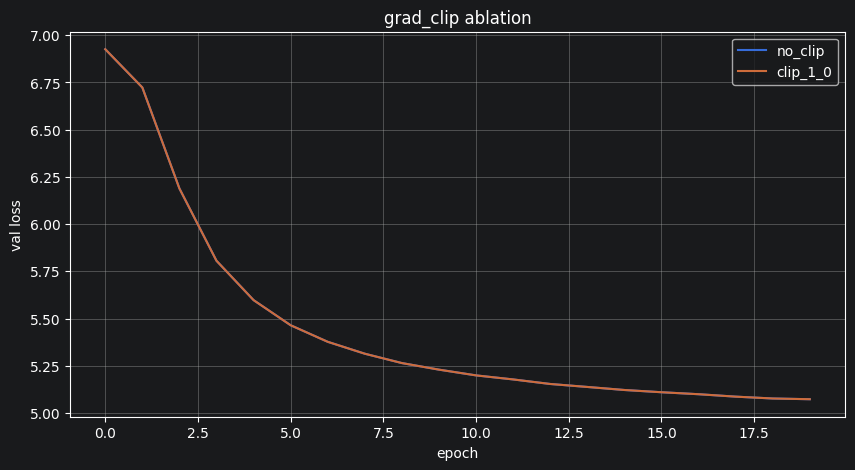

no_clip final val: 5.0733 best val: 5.0733 elapsed: 47.7
clip_1_0 final val: 5.0733 best val: 5.0733 elapsed: 49.2


In [ ]:
# ABLATION_GRAD_CLIP
grad_clip_results = run_ablation(
    "grad_clip",
    [
        ("no_clip", {}),
        ("clip_1_0", {"grad_clip": 1.0}),
    ],
    epochs=20,
)


## 50 epoch ablation

?? ??? ? hyperparameter ????? 50 epoch? ?? ?? ????. ? ????? ?? ? 1?? ??? ? 1?? ???? ??.


In [ ]:
# ABLATION50_COMMON_SETUP
# 50 epoch ???? ?? ablation ????? ?? ??? ?? ???? ?? ?? ?? ?

from pathlib import Path
import json
import time
import random

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from src.bpe import BPETokenizer
from src.dataset import GPTDataset
from src.model import GPTModel, FeedForward, GELU
from src.train import calc_loss_batch, calc_loss_loader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

TRAIN_TEXT = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
VAL_TEXT = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

ABLATION50_EPOCHS = 50
ABLATION50_SEED = 42
ABLATION50_DIR = Path("checkpoints")
ABLATION50_FIG_DIR = Path("figures")
ABLATION50_DIR.mkdir(exist_ok=True)
ABLATION50_FIG_DIR.mkdir(exist_ok=True)

TOKENIZER_CACHE = {}
IDS_CACHE = {}

BASE_CONFIG_50 = {
    "vocab_size": 2000,
    "context_length": 128,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}


def set_seed(seed=ABLATION50_SEED):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_tokenizer50(vocab_size):
    if vocab_size in TOKENIZER_CACHE:
        return TOKENIZER_CACHE[vocab_size]

    path = Path(f"data/vocab_ablation_{vocab_size}.json")
    tokenizer = BPETokenizer(vocab_size=vocab_size)

    if path.exists():
        tokenizer.load(path)
        print(f"tokenizer loaded: {path}")
    else:
        print(f"train tokenizer: vocab_size={vocab_size}")
        tokenizer.train(TRAIN_TEXT)
        tokenizer.save(path)
        print(f"tokenizer saved: {path}")

    TOKENIZER_CACHE[vocab_size] = tokenizer
    return tokenizer


def get_ids50(vocab_size):
    if vocab_size in IDS_CACHE:
        return IDS_CACHE[vocab_size]

    tokenizer = get_tokenizer50(vocab_size)
    train_ids = tokenizer.encode(TRAIN_TEXT, add_bos_eos=False)
    val_ids = tokenizer.encode(VAL_TEXT, add_bos_eos=False)
    IDS_CACHE[vocab_size] = (train_ids, val_ids)
    print(f"encoded vocab={vocab_size}: train={len(train_ids)}, val={len(val_ids)}")
    return train_ids, val_ids


def make_activation50(name):
    if name == "gelu":
        return GELU()
    if name == "relu":
        return nn.ReLU()
    if name == "silu":
        return nn.SiLU()
    if name == "sigmoid":
        return nn.Sigmoid()
    raise ValueError(name)


def apply_model_overrides50(model, config, overrides):
    activation = overrides.get("activation", "gelu")
    ffn_mult = overrides.get("ffn_mult", 4)

    for block in model.blocks:
        block.ffn = FeedForward(
            config["emb_dim"],
            dropout=config["drop_rate"],
            mult=ffn_mult,
        ).to(DEVICE)
        block.ffn.net[1] = make_activation50(activation)


def make_loader50(token_ids, context_length, batch_size, shuffle, seed):
    dataset = GPTDataset(token_ids, context_length)
    generator = torch.Generator()
    generator.manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator,
        drop_last=False,
        num_workers=0,
    )


def make_optimizer50(model, overrides):
    lr = overrides.get("learning_rate", 3e-4)
    weight_decay = overrides.get("weight_decay", 0.0)
    optimizer_name = overrides.get("optimizer", "adamw")

    if optimizer_name == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    if optimizer_name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if optimizer_name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    raise ValueError(optimizer_name)


def run_one_variant50(category, label, overrides, epochs=ABLATION50_EPOCHS, seed=ABLATION50_SEED):
    set_seed(seed)

    config = dict(BASE_CONFIG_50)
    for key in ["vocab_size", "context_length", "emb_dim", "n_heads", "n_layers", "drop_rate", "qkv_bias"]:
        if key in overrides:
            config[key] = overrides[key]

    batch_size = overrides.get("batch_size", 32)
    vocab_size = config["vocab_size"]
    context_length = config["context_length"]

    train_ids, val_ids = get_ids50(vocab_size)
    train_loader = make_loader50(train_ids, context_length, batch_size, True, seed)
    val_loader = make_loader50(val_ids, context_length, batch_size, False, seed)

    model = GPTModel(config).to(DEVICE)
    apply_model_overrides50(model, config, overrides)
    optimizer = make_optimizer50(model, overrides)

    train_losses = []
    val_losses = []
    start = time.perf_counter()

    print(f"\n[{category}/{label}] start epochs={epochs} overrides={overrides}")
    print(f"train batches={len(train_loader)}, val batches={len(val_loader)}")

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_losses = []

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, DEVICE)
            loss.backward()

            if overrides.get("grad_clip") is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), overrides["grad_clip"])

            optimizer.step()
            epoch_losses.append(loss.item())

        train_loss = float(sum(epoch_losses) / len(epoch_losses))
        val_loss = calc_loss_loader(val_loader, model, DEVICE, num_batches=None)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"{category}/{label} epoch {epoch:03d}/{epochs} "
            f"train {train_loss:.4f} val {val_loss:.4f}"
        )

    elapsed = time.perf_counter() - start
    return {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "elapsed": elapsed,
        "overrides": overrides,
        "config": config,
        "batch_size": batch_size,
        "epochs": epochs,
        "seed": seed,
    }


def run_ablation50(category, variants, epochs=ABLATION50_EPOCHS, seed=ABLATION50_SEED):
    results = {}
    for label, overrides in variants:
        results[label] = run_one_variant50(category, label, overrides, epochs=epochs, seed=seed)

    out_path = ABLATION50_DIR / f"ablation50_{category}.json"
    out_path.write_text(json.dumps(results, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"saved: {out_path}")
    return results


def plot_ablation50(category, title=None):
    path = ABLATION50_DIR / f"ablation50_{category}.json"
    data = json.loads(path.read_text(encoding="utf-8"))

    labels = list(data.keys())
    final_vals = [data[label]["val_loss"][-1] for label in labels]
    best_idx = min(range(len(final_vals)), key=lambda i: final_vals[i])

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    for label in labels:
        vals = data[label]["val_loss"]
        axes[0].plot(range(1, len(vals) + 1), vals, marker="o", markersize=3, label=label)

    axes[0].set_title(f"{title or category} validation loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("validation loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    colors = ["#4e79a7"] * len(labels)
    colors[best_idx] = "#59a14f"
    bars = axes[1].bar(labels, final_vals, color=colors)
    axes[1].set_title("final validation loss")
    axes[1].set_ylabel("validation loss")
    axes[1].grid(True, axis="y", alpha=0.3)
    axes[1].tick_params(axis="x", rotation=25)

    for bar, val in zip(bars, final_vals):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            val,
            f"{val:.4f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    fig.suptitle(f"50 epoch ablation: {title or category}")
    fig.tight_layout()

    out_path = ABLATION50_FIG_DIR / f"ablation50_{category}.png"
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"saved: {out_path}")


device: cuda


### ABLATION50 - Activation


In [ ]:
# ABLATION50_ACTIVATION_TRAIN
activation50_results = run_ablation50(
    "activation",
    [
        ("gelu", {"activation": "gelu"}),
        ("relu", {"activation": "relu"}),
        ("silu", {"activation": "silu"}),
        ("sigmoid", {"activation": "sigmoid"}),
    ],
    epochs=50,
)


tokenizer loaded: data\vocab_ablation_2000.json
encoded vocab=2000: train=900849, val=78686

[activation/gelu] start epochs=50 overrides={'activation': 'gelu'}
train batches=220, val batches=20
activation/gelu epoch 001/50 train 7.0622 val 6.9266
activation/gelu epoch 002/50 train 6.8764 val 6.7386
activation/gelu epoch 003/50 train 6.5212 val 6.1774
activation/gelu epoch 004/50 train 6.0501 val 5.7988
activation/gelu epoch 005/50 train 5.7660 val 5.5858
activation/gelu epoch 006/50 train 5.5889 val 5.4563
activation/gelu epoch 007/50 train 5.4683 val 5.3702
activation/gelu epoch 008/50 train 5.3792 val 5.3074
activation/gelu epoch 009/50 train 5.3115 val 5.2601
activation/gelu epoch 010/50 train 5.2573 val 5.2232
activation/gelu epoch 011/50 train 5.2140 val 5.1986
activation/gelu epoch 012/50 train 5.1765 val 5.1701
activation/gelu epoch 013/50 train 5.1441 val 5.1517
activation/gelu epoch 014/50 train 5.1156 val 5.1347
activation/gelu epoch 015/50 train 5.0911 val 5.1184
activation/

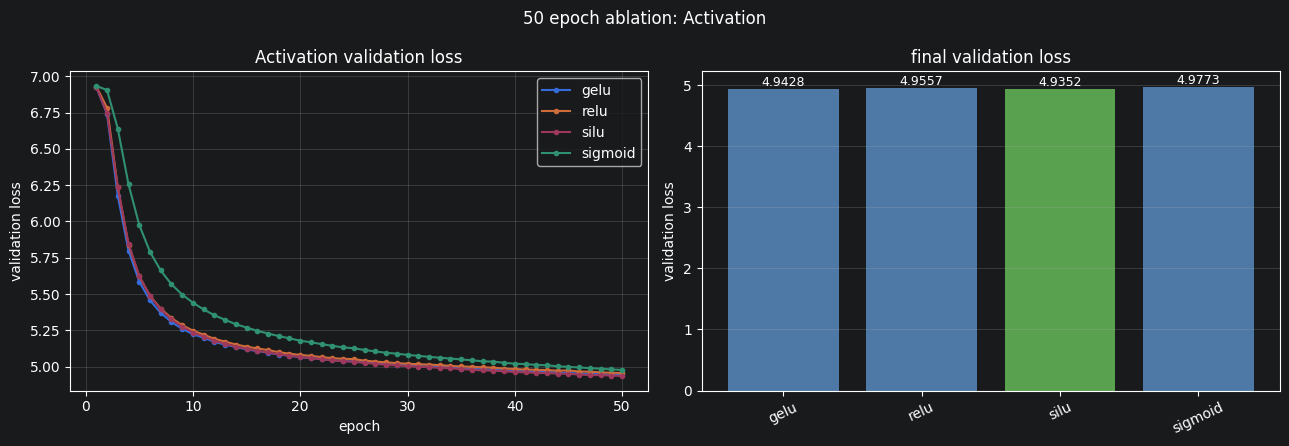

saved: figures\ablation50_activation.png


In [ ]:
# ABLATION50_ACTIVATION_PLOT
plot_ablation50("activation", "Activation")


### ABLATION50 - Dropout


In [ ]:
# ABLATION50_DROPOUT_TRAIN
dropout50_results = run_ablation50(
    "dropout",
    [
        ("drop_0_0", {"drop_rate": 0.0}),
        ("drop_0_1", {"drop_rate": 0.1}),
        ("drop_0_3", {"drop_rate": 0.3}),
    ],
    epochs=50,
)



[dropout/drop_0_0] start epochs=50 overrides={'drop_rate': 0.0}
train batches=220, val batches=20
dropout/drop_0_0 epoch 001/50 train 7.0505 val 6.9235
dropout/drop_0_0 epoch 002/50 train 6.8243 val 6.6307
dropout/drop_0_0 epoch 003/50 train 6.2732 val 5.9926
dropout/drop_0_0 epoch 004/50 train 5.7764 val 5.6667
dropout/drop_0_0 epoch 005/50 train 5.5071 val 5.4798
dropout/drop_0_0 epoch 006/50 train 5.3412 val 5.3692
dropout/drop_0_0 epoch 007/50 train 5.2282 val 5.2968
dropout/drop_0_0 epoch 008/50 train 5.1443 val 5.2438
dropout/drop_0_0 epoch 009/50 train 5.0778 val 5.2052
dropout/drop_0_0 epoch 010/50 train 5.0237 val 5.1787
dropout/drop_0_0 epoch 011/50 train 4.9770 val 5.1595
dropout/drop_0_0 epoch 012/50 train 4.9363 val 5.1388
dropout/drop_0_0 epoch 013/50 train 4.9001 val 5.1269
dropout/drop_0_0 epoch 014/50 train 4.8667 val 5.1168
dropout/drop_0_0 epoch 015/50 train 4.8362 val 5.1095
dropout/drop_0_0 epoch 016/50 train 4.8078 val 5.1047
dropout/drop_0_0 epoch 017/50 train 4

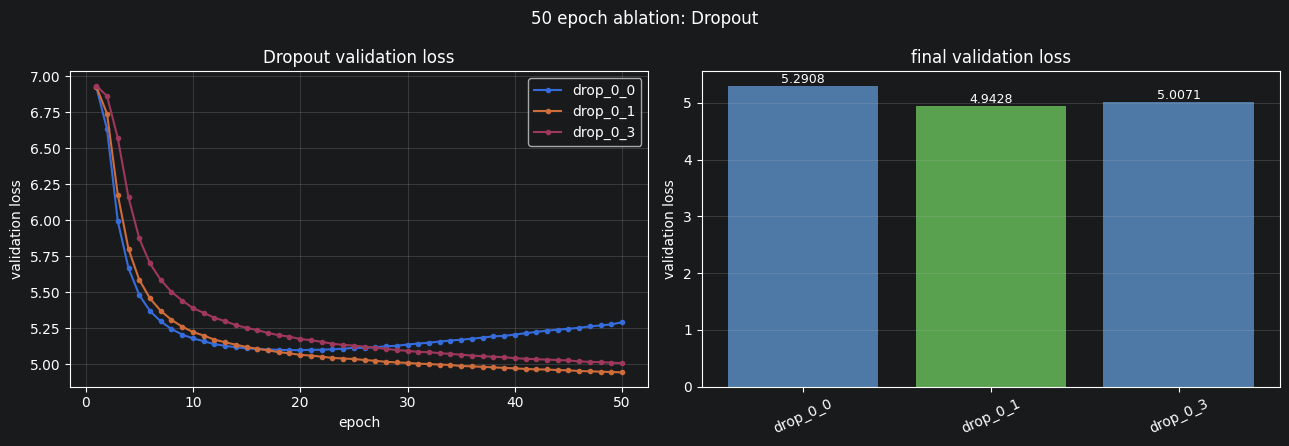

saved: figures\ablation50_dropout.png


In [ ]:
# ABLATION50_DROPOUT_PLOT
plot_ablation50("dropout", "Dropout")


### ABLATION50 - Learning rate


In [ ]:
# ABLATION50_LEARNING_RATE_TRAIN
learning_rate50_results = run_ablation50(
    "learning_rate",
    [
        ("lr_1e_4", {"learning_rate": 1e-4}),
        ("lr_3e_4", {"learning_rate": 3e-4}),
        ("lr_1e_3", {"learning_rate": 1e-3}),
    ],
    epochs=50,
)



[learning_rate/lr_1e_4] start epochs=50 overrides={'learning_rate': 0.0001}
train batches=220, val batches=20
learning_rate/lr_1e_4 epoch 001/50 train 7.2626 val 6.9456
learning_rate/lr_1e_4 epoch 002/50 train 6.9416 val 6.9307
learning_rate/lr_1e_4 epoch 003/50 train 6.9317 val 6.9213
learning_rate/lr_1e_4 epoch 004/50 train 6.9152 val 6.8937
learning_rate/lr_1e_4 epoch 005/50 train 6.8654 val 6.8118
learning_rate/lr_1e_4 epoch 006/50 train 6.7660 val 6.6799
learning_rate/lr_1e_4 epoch 007/50 train 6.6275 val 6.5076
learning_rate/lr_1e_4 epoch 008/50 train 6.4563 val 6.3079
learning_rate/lr_1e_4 epoch 009/50 train 6.2844 val 6.1428
learning_rate/lr_1e_4 epoch 010/50 train 6.1431 val 6.0094
learning_rate/lr_1e_4 epoch 011/50 train 6.0277 val 5.9006
learning_rate/lr_1e_4 epoch 012/50 train 5.9310 val 5.8103
learning_rate/lr_1e_4 epoch 013/50 train 5.8468 val 5.7339
learning_rate/lr_1e_4 epoch 014/50 train 5.7743 val 5.6689
learning_rate/lr_1e_4 epoch 015/50 train 5.7114 val 5.6116
lear

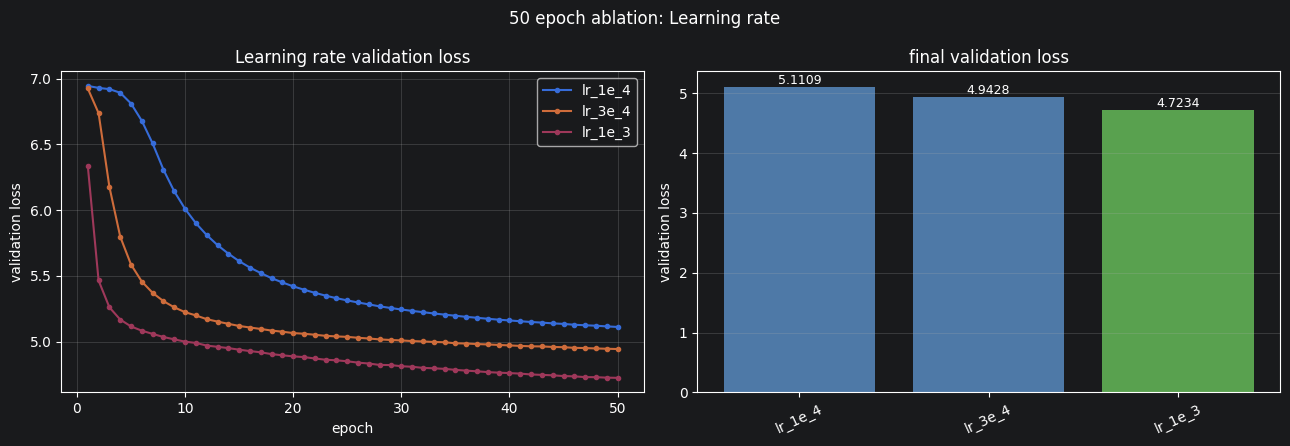

saved: figures\ablation50_learning_rate.png


In [ ]:
# ABLATION50_LEARNING_RATE_PLOT
plot_ablation50("learning_rate", "Learning rate")


### ABLATION50 - Optimizer and weight decay


In [ ]:
# ABLATION50_OPTIMIZER_WEIGHT_DECAY_TRAIN
optimizer_weight_decay50_results = run_ablation50(
    "optimizer_weight_decay",
    [
        ("adamw_wd_0", {"optimizer": "adamw", "weight_decay": 0.0}),
        ("adamw_wd_0_01", {"optimizer": "adamw", "weight_decay": 0.01}),
        ("adam_wd_0", {"optimizer": "adam", "weight_decay": 0.0}),
        ("sgd_lr_1e_2", {"optimizer": "sgd", "learning_rate": 1e-2}),
    ],
    epochs=50,
)



[optimizer_weight_decay/adamw_wd_0] start epochs=50 overrides={'optimizer': 'adamw', 'weight_decay': 0.0}
train batches=220, val batches=20
optimizer_weight_decay/adamw_wd_0 epoch 001/50 train 7.0622 val 6.9266
optimizer_weight_decay/adamw_wd_0 epoch 002/50 train 6.8764 val 6.7386
optimizer_weight_decay/adamw_wd_0 epoch 003/50 train 6.5212 val 6.1774
optimizer_weight_decay/adamw_wd_0 epoch 004/50 train 6.0501 val 5.7988
optimizer_weight_decay/adamw_wd_0 epoch 005/50 train 5.7660 val 5.5858
optimizer_weight_decay/adamw_wd_0 epoch 006/50 train 5.5889 val 5.4563
optimizer_weight_decay/adamw_wd_0 epoch 007/50 train 5.4683 val 5.3702
optimizer_weight_decay/adamw_wd_0 epoch 008/50 train 5.3792 val 5.3074
optimizer_weight_decay/adamw_wd_0 epoch 009/50 train 5.3115 val 5.2601
optimizer_weight_decay/adamw_wd_0 epoch 010/50 train 5.2573 val 5.2232
optimizer_weight_decay/adamw_wd_0 epoch 011/50 train 5.2140 val 5.1986
optimizer_weight_decay/adamw_wd_0 epoch 012/50 train 5.1765 val 5.1701
optimiz

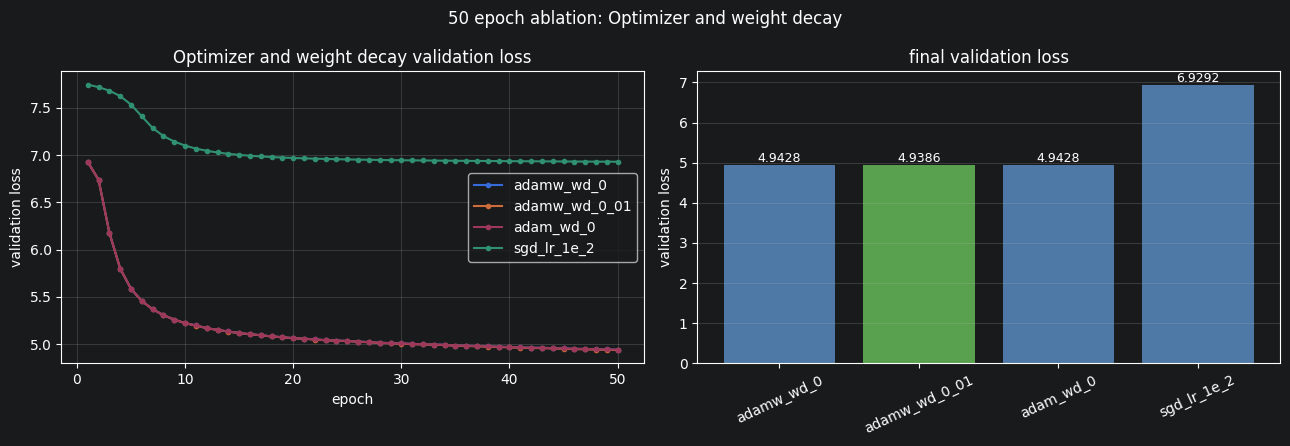

saved: figures\ablation50_optimizer_weight_decay.png


In [ ]:
# ABLATION50_OPTIMIZER_WEIGHT_DECAY_PLOT
plot_ablation50("optimizer_weight_decay", "Optimizer and weight decay")


### ABLATION50 - Context length


In [ ]:
# ABLATION50_CONTEXT_LENGTH_TRAIN
context_length50_results = run_ablation50(
    "context_length",
    [
        ("ctx_64", {"context_length": 64}),
        ("ctx_128", {"context_length": 128}),
        ("ctx_256", {"context_length": 256}),
    ],
    epochs=50,
)



[context_length/ctx_64] start epochs=50 overrides={'context_length': 64}
train batches=440, val batches=39
context_length/ctx_64 epoch 001/50 train 7.0005 val 6.8697
context_length/ctx_64 epoch 002/50 train 6.5559 val 6.0686
context_length/ctx_64 epoch 003/50 train 5.9072 val 5.6117
context_length/ctx_64 epoch 004/50 train 5.5870 val 5.4054
context_length/ctx_64 epoch 005/50 train 5.4140 val 5.2949
context_length/ctx_64 epoch 006/50 train 5.3044 val 5.2193
context_length/ctx_64 epoch 007/50 train 5.2286 val 5.1734
context_length/ctx_64 epoch 008/50 train 5.1708 val 5.1310
context_length/ctx_64 epoch 009/50 train 5.1242 val 5.1025
context_length/ctx_64 epoch 010/50 train 5.0849 val 5.0762
context_length/ctx_64 epoch 011/50 train 5.0495 val 5.0554
context_length/ctx_64 epoch 012/50 train 5.0216 val 5.0361
context_length/ctx_64 epoch 013/50 train 4.9948 val 5.0191
context_length/ctx_64 epoch 014/50 train 4.9699 val 5.0049
context_length/ctx_64 epoch 015/50 train 4.9480 val 4.9879
context

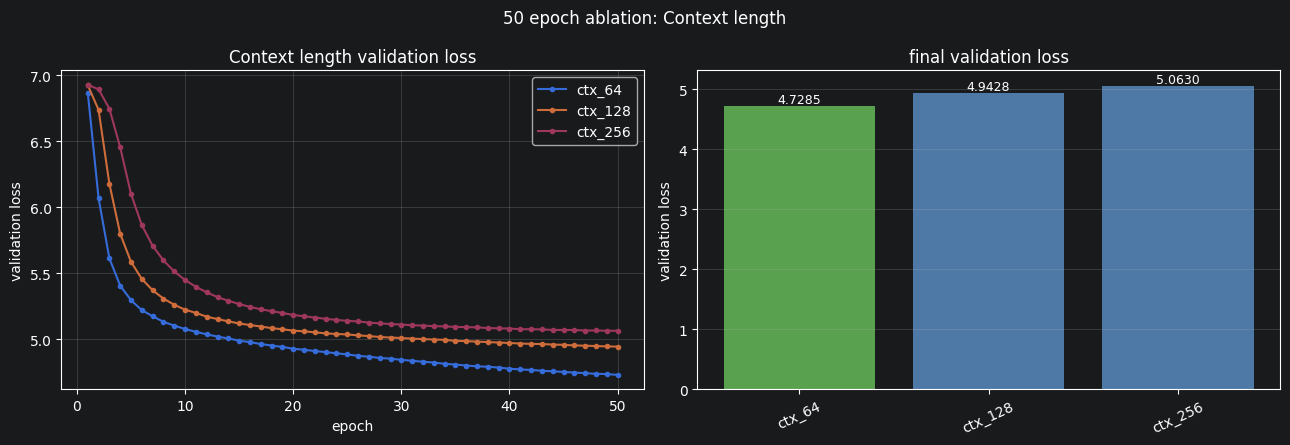

saved: figures\ablation50_context_length.png


In [ ]:
# ABLATION50_CONTEXT_LENGTH_PLOT
plot_ablation50("context_length", "Context length")


### ABLATION50 - Vocab size


In [ ]:
# ABLATION50_VOCAB_SIZE_TRAIN
vocab_size50_results = run_ablation50(
    "vocab_size",
    [
        ("vocab_1000", {"vocab_size": 1000}),
        ("vocab_2000", {"vocab_size": 2000}),
        ("vocab_4000", {"vocab_size": 4000}),
    ],
    epochs=50,
)


tokenizer loaded: data\vocab_ablation_1000.json
encoded vocab=1000: train=1138662, val=99258

[vocab_size/vocab_1000] start epochs=50 overrides={'vocab_size': 1000}
train batches=278, val batches=25
vocab_size/vocab_1000 epoch 001/50 train 6.2620 val 5.8322
vocab_size/vocab_1000 epoch 002/50 train 5.4127 val 4.9932
vocab_size/vocab_1000 epoch 003/50 train 4.9290 val 4.7131
vocab_size/vocab_1000 epoch 004/50 train 4.7259 val 4.5840
vocab_size/vocab_1000 epoch 005/50 train 4.6148 val 4.5117
vocab_size/vocab_1000 epoch 006/50 train 4.5432 val 4.4598
vocab_size/vocab_1000 epoch 007/50 train 4.4911 val 4.4195
vocab_size/vocab_1000 epoch 008/50 train 4.4484 val 4.3882
vocab_size/vocab_1000 epoch 009/50 train 4.4117 val 4.3612
vocab_size/vocab_1000 epoch 010/50 train 4.3804 val 4.3322
vocab_size/vocab_1000 epoch 011/50 train 4.3516 val 4.3042
vocab_size/vocab_1000 epoch 012/50 train 4.3242 val 4.2815
vocab_size/vocab_1000 epoch 013/50 train 4.2995 val 4.2588
vocab_size/vocab_1000 epoch 014/50

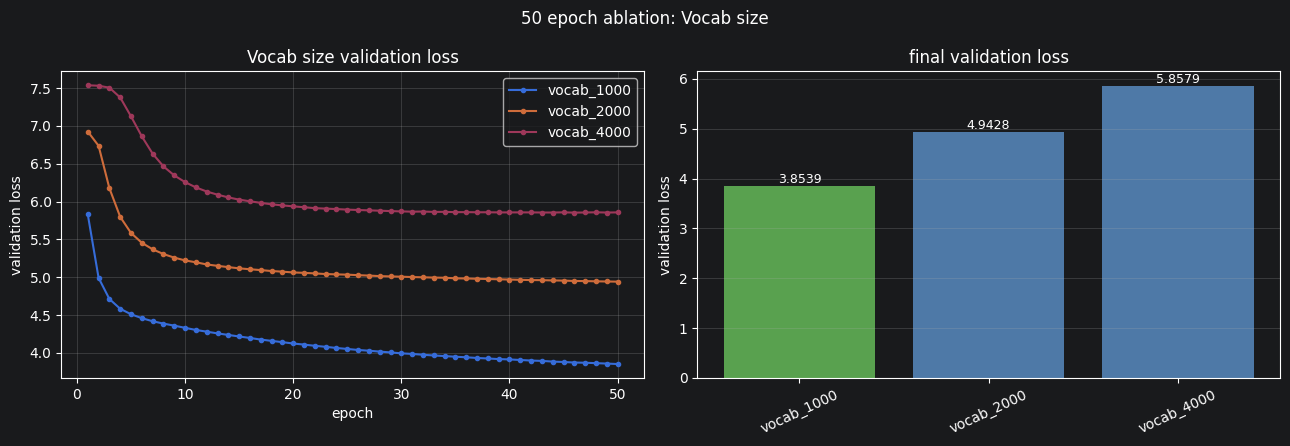

saved: figures\ablation50_vocab_size.png


In [ ]:
# ABLATION50_VOCAB_SIZE_PLOT
plot_ablation50("vocab_size", "Vocab size")


### ABLATION50 - Embedding dimension


In [ ]:
# ABLATION50_EMB_DIM_TRAIN
emb_dim50_results = run_ablation50(
    "emb_dim",
    [
        ("emb_64", {"emb_dim": 64}),
        ("emb_128", {"emb_dim": 128}),
        ("emb_256", {"emb_dim": 256}),
    ],
    epochs=50,
)



[emb_dim/emb_64] start epochs=50 overrides={'emb_dim': 64}
train batches=220, val batches=20
emb_dim/emb_64 epoch 001/50 train 7.1534 val 6.9366
emb_dim/emb_64 epoch 002/50 train 6.9371 val 6.9263
emb_dim/emb_64 epoch 003/50 train 6.9167 val 6.8822
emb_dim/emb_64 epoch 004/50 train 6.8282 val 6.7238
emb_dim/emb_64 epoch 005/50 train 6.6440 val 6.4772
emb_dim/emb_64 epoch 006/50 train 6.4186 val 6.2289
emb_dim/emb_64 epoch 007/50 train 6.2127 val 6.0344
emb_dim/emb_64 epoch 008/50 train 6.0493 val 5.8835
emb_dim/emb_64 epoch 009/50 train 5.9219 val 5.7701
emb_dim/emb_64 epoch 010/50 train 5.8196 val 5.6801
emb_dim/emb_64 epoch 011/50 train 5.7363 val 5.6106
emb_dim/emb_64 epoch 012/50 train 5.6693 val 5.5510
emb_dim/emb_64 epoch 013/50 train 5.6105 val 5.5022
emb_dim/emb_64 epoch 014/50 train 5.5616 val 5.4597
emb_dim/emb_64 epoch 015/50 train 5.5185 val 5.4242
emb_dim/emb_64 epoch 016/50 train 5.4804 val 5.3931
emb_dim/emb_64 epoch 017/50 train 5.4467 val 5.3670
emb_dim/emb_64 epoch 0

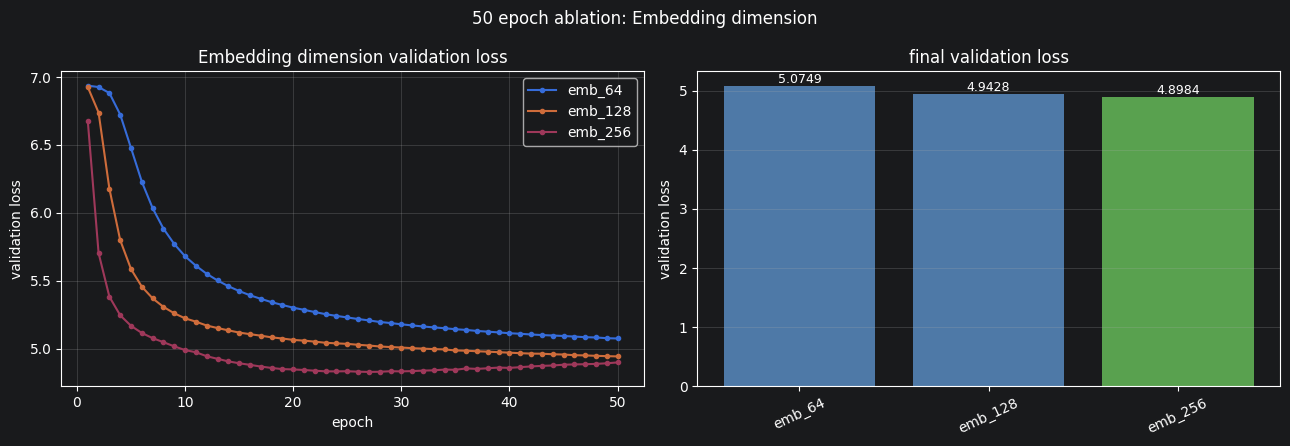

saved: figures\ablation50_emb_dim.png


In [ ]:
# ABLATION50_EMB_DIM_PLOT
plot_ablation50("emb_dim", "Embedding dimension")


### ABLATION50 - Number of layers


In [ ]:
# ABLATION50_N_LAYERS_TRAIN
n_layers50_results = run_ablation50(
    "n_layers",
    [
        ("layers_1", {"n_layers": 1}),
        ("layers_2", {"n_layers": 2}),
        ("layers_4", {"n_layers": 4}),
    ],
    epochs=50,
)



[n_layers/layers_1] start epochs=50 overrides={'n_layers': 1}
train batches=220, val batches=20
n_layers/layers_1 epoch 001/50 train 7.1132 val 6.9125
n_layers/layers_1 epoch 002/50 train 6.8690 val 6.7612
n_layers/layers_1 epoch 003/50 train 6.6252 val 6.3897
n_layers/layers_1 epoch 004/50 train 6.2470 val 5.9803
n_layers/layers_1 epoch 005/50 train 5.9212 val 5.7171
n_layers/layers_1 epoch 006/50 train 5.7120 val 5.5639
n_layers/layers_1 epoch 007/50 train 5.5757 val 5.4665
n_layers/layers_1 epoch 008/50 train 5.4802 val 5.3955
n_layers/layers_1 epoch 009/50 train 5.4081 val 5.3445
n_layers/layers_1 epoch 010/50 train 5.3503 val 5.3041
n_layers/layers_1 epoch 011/50 train 5.3043 val 5.2729
n_layers/layers_1 epoch 012/50 train 5.2662 val 5.2448
n_layers/layers_1 epoch 013/50 train 5.2324 val 5.2224
n_layers/layers_1 epoch 014/50 train 5.2014 val 5.2031
n_layers/layers_1 epoch 015/50 train 5.1758 val 5.1850
n_layers/layers_1 epoch 016/50 train 5.1517 val 5.1705
n_layers/layers_1 epoch

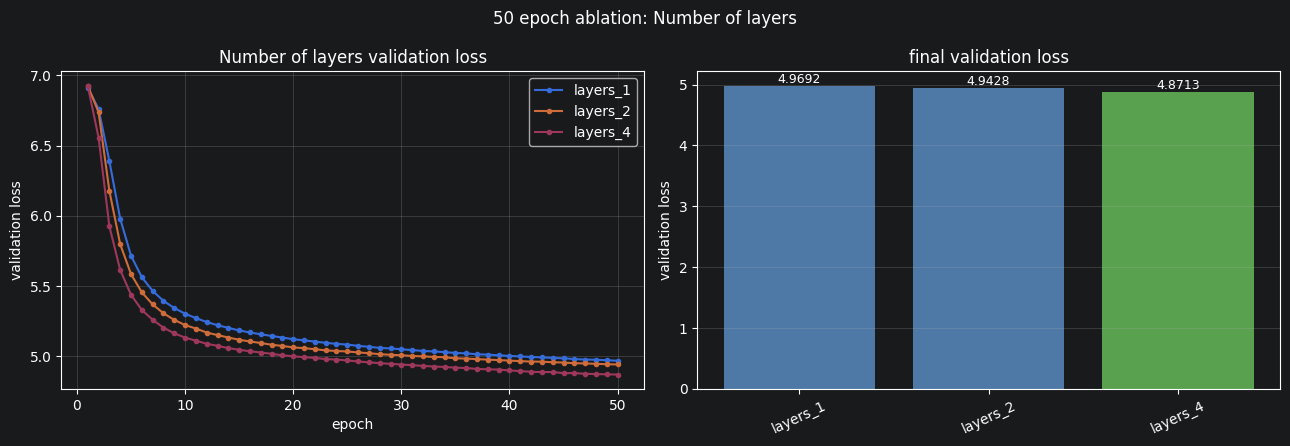

saved: figures\ablation50_n_layers.png


In [ ]:
# ABLATION50_N_LAYERS_PLOT
plot_ablation50("n_layers", "Number of layers")


### ABLATION50 - Number of heads


In [ ]:
# ABLATION50_N_HEADS_TRAIN
n_heads50_results = run_ablation50(
    "n_heads",
    [
        ("heads_2", {"n_heads": 2}),
        ("heads_4", {"n_heads": 4}),
        ("heads_8", {"n_heads": 8}),
    ],
    epochs=50,
)



[n_heads/heads_2] start epochs=50 overrides={'n_heads': 2}
train batches=220, val batches=20
n_heads/heads_2 epoch 001/50 train 7.0624 val 6.9267
n_heads/heads_2 epoch 002/50 train 6.8768 val 6.7391
n_heads/heads_2 epoch 003/50 train 6.5222 val 6.1799
n_heads/heads_2 epoch 004/50 train 6.0526 val 5.8043
n_heads/heads_2 epoch 005/50 train 5.7700 val 5.5906
n_heads/heads_2 epoch 006/50 train 5.5925 val 5.4602
n_heads/heads_2 epoch 007/50 train 5.4711 val 5.3741
n_heads/heads_2 epoch 008/50 train 5.3825 val 5.3092
n_heads/heads_2 epoch 009/50 train 5.3144 val 5.2621
n_heads/heads_2 epoch 010/50 train 5.2616 val 5.2249
n_heads/heads_2 epoch 011/50 train 5.2167 val 5.1980
n_heads/heads_2 epoch 012/50 train 5.1789 val 5.1709
n_heads/heads_2 epoch 013/50 train 5.1470 val 5.1524
n_heads/heads_2 epoch 014/50 train 5.1175 val 5.1354
n_heads/heads_2 epoch 015/50 train 5.0940 val 5.1187
n_heads/heads_2 epoch 016/50 train 5.0709 val 5.1055
n_heads/heads_2 epoch 017/50 train 5.0499 val 5.0937
n_hea

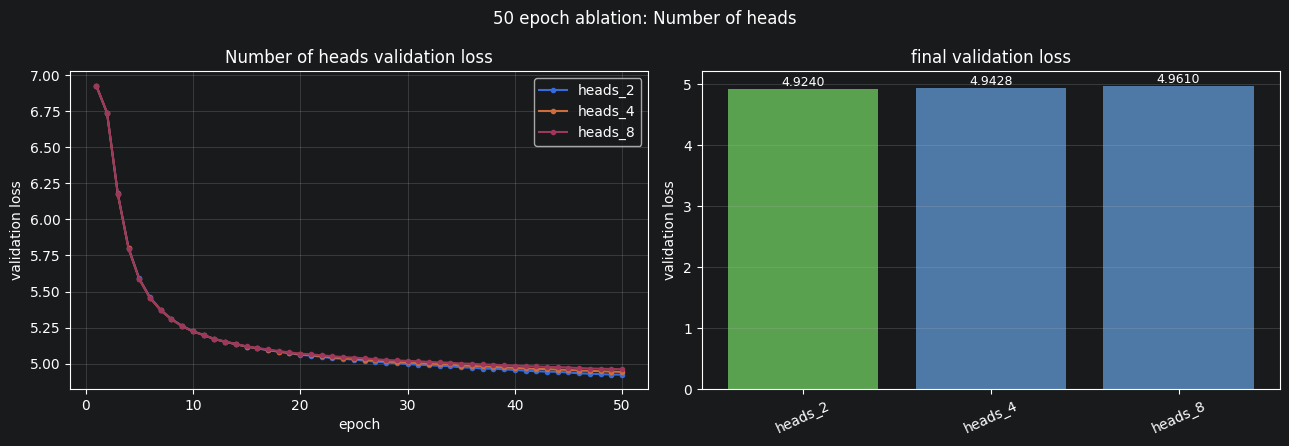

saved: figures\ablation50_n_heads.png


In [ ]:
# ABLATION50_N_HEADS_PLOT
plot_ablation50("n_heads", "Number of heads")


### ABLATION50 - FFN expansion ratio


In [ ]:
# ABLATION50_FFN_MULT_TRAIN
ffn_mult50_results = run_ablation50(
    "ffn_mult",
    [
        ("mult_2", {"ffn_mult": 2}),
        ("mult_4", {"ffn_mult": 4}),
        ("mult_8", {"ffn_mult": 8}),
    ],
    epochs=50,
)



[ffn_mult/mult_2] start epochs=50 overrides={'ffn_mult': 2}
train batches=220, val batches=20
ffn_mult/mult_2 epoch 001/50 train 7.0785 val 6.9282
ffn_mult/mult_2 epoch 002/50 train 6.9005 val 6.8149
ffn_mult/mult_2 epoch 003/50 train 6.6549 val 6.3841
ffn_mult/mult_2 epoch 004/50 train 6.2198 val 5.9576
ffn_mult/mult_2 epoch 005/50 train 5.9029 val 5.7195
ffn_mult/mult_2 epoch 006/50 train 5.7093 val 5.5732
ffn_mult/mult_2 epoch 007/50 train 5.5784 val 5.4759
ffn_mult/mult_2 epoch 008/50 train 5.4819 val 5.4042
ffn_mult/mult_2 epoch 009/50 train 5.4089 val 5.3497
ffn_mult/mult_2 epoch 010/50 train 5.3498 val 5.3059
ffn_mult/mult_2 epoch 011/50 train 5.3020 val 5.2736
ffn_mult/mult_2 epoch 012/50 train 5.2605 val 5.2432
ffn_mult/mult_2 epoch 013/50 train 5.2243 val 5.2189
ffn_mult/mult_2 epoch 014/50 train 5.1941 val 5.1974
ffn_mult/mult_2 epoch 015/50 train 5.1677 val 5.1804
ffn_mult/mult_2 epoch 016/50 train 5.1420 val 5.1634
ffn_mult/mult_2 epoch 017/50 train 5.1189 val 5.1501
ffn_

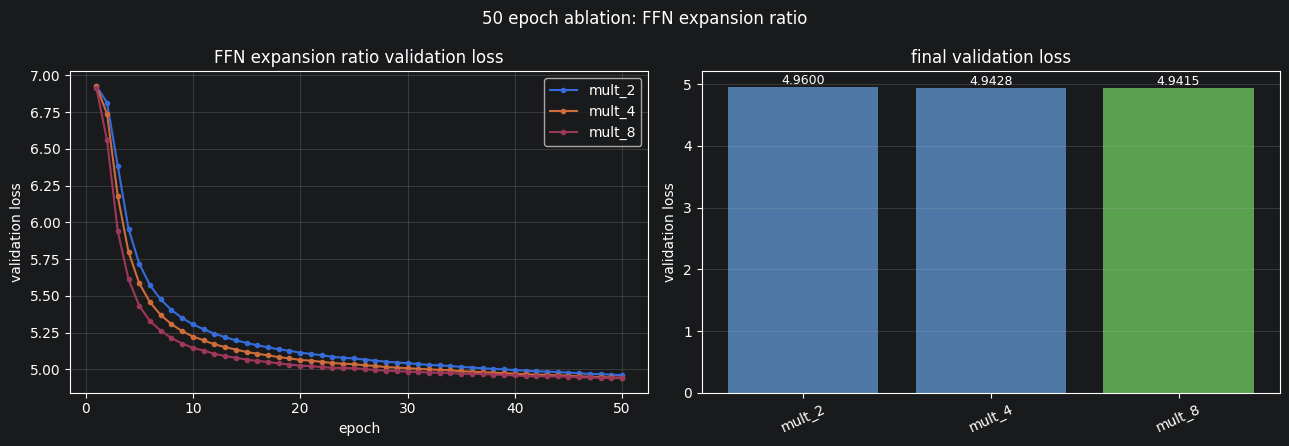

saved: figures\ablation50_ffn_mult.png


In [ ]:
# ABLATION50_FFN_MULT_PLOT
plot_ablation50("ffn_mult", "FFN expansion ratio")


### ABLATION50 - Gradient clipping


In [ ]:
# ABLATION50_GRAD_CLIP_TRAIN
grad_clip50_results = run_ablation50(
    "grad_clip",
    [
        ("no_clip", {}),
        ("clip_1_0", {"grad_clip": 1.0}),
    ],
    epochs=50,
)



[grad_clip/no_clip] start epochs=50 overrides={}
train batches=220, val batches=20
grad_clip/no_clip epoch 001/50 train 7.0622 val 6.9266
grad_clip/no_clip epoch 002/50 train 6.8764 val 6.7386
grad_clip/no_clip epoch 003/50 train 6.5212 val 6.1774
grad_clip/no_clip epoch 004/50 train 6.0501 val 5.7988
grad_clip/no_clip epoch 005/50 train 5.7660 val 5.5858
grad_clip/no_clip epoch 006/50 train 5.5889 val 5.4563
grad_clip/no_clip epoch 007/50 train 5.4683 val 5.3702
grad_clip/no_clip epoch 008/50 train 5.3792 val 5.3074
grad_clip/no_clip epoch 009/50 train 5.3115 val 5.2601
grad_clip/no_clip epoch 010/50 train 5.2573 val 5.2232
grad_clip/no_clip epoch 011/50 train 5.2140 val 5.1986
grad_clip/no_clip epoch 012/50 train 5.1765 val 5.1701
grad_clip/no_clip epoch 013/50 train 5.1441 val 5.1517
grad_clip/no_clip epoch 014/50 train 5.1156 val 5.1347
grad_clip/no_clip epoch 015/50 train 5.0911 val 5.1184
grad_clip/no_clip epoch 016/50 train 5.0684 val 5.1066
grad_clip/no_clip epoch 017/50 train

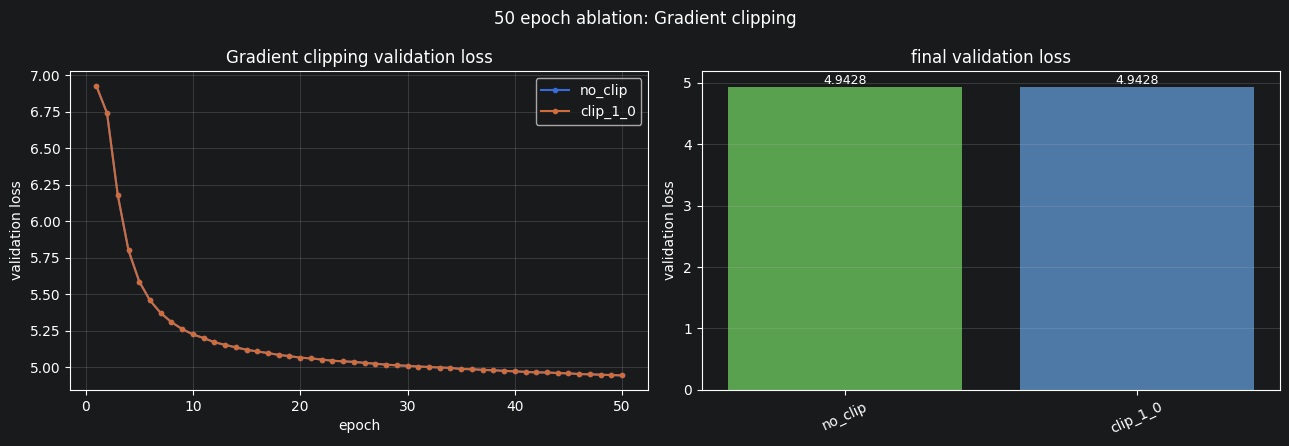

saved: figures\ablation50_grad_clip.png


In [ ]:
# ABLATION50_GRAD_CLIP_PLOT
plot_ablation50("grad_clip", "Gradient clipping")


### ABLATION50 - Batch size


In [ ]:
# ABLATION50_BATCH_SIZE_TRAIN
batch_size50_results = run_ablation50(
    "batch_size",
    [
        ("bs_16", {"batch_size": 16}),
        ("bs_32", {"batch_size": 32}),
        ("bs_64", {"batch_size": 64}),
    ],
    epochs=50,
)



[batch_size/bs_16] start epochs=50 overrides={'batch_size': 16}
train batches=440, val batches=39
batch_size/bs_16 epoch 001/50 train 7.0057 val 6.8828
batch_size/bs_16 epoch 002/50 train 6.6224 val 6.1771
batch_size/bs_16 epoch 003/50 train 5.9851 val 5.6921
batch_size/bs_16 epoch 004/50 train 5.6521 val 5.4753
batch_size/bs_16 epoch 005/50 train 5.4711 val 5.3566
batch_size/bs_16 epoch 006/50 train 5.3578 val 5.2820
batch_size/bs_16 epoch 007/50 train 5.2760 val 5.2340
batch_size/bs_16 epoch 008/50 train 5.2151 val 5.1925
batch_size/bs_16 epoch 009/50 train 5.1673 val 5.1617
batch_size/bs_16 epoch 010/50 train 5.1265 val 5.1381
batch_size/bs_16 epoch 011/50 train 5.0927 val 5.1228
batch_size/bs_16 epoch 012/50 train 5.0624 val 5.1007
batch_size/bs_16 epoch 013/50 train 5.0368 val 5.0864
batch_size/bs_16 epoch 014/50 train 5.0129 val 5.0735
batch_size/bs_16 epoch 015/50 train 4.9919 val 5.0631
batch_size/bs_16 epoch 016/50 train 4.9739 val 5.0497
batch_size/bs_16 epoch 017/50 train 4

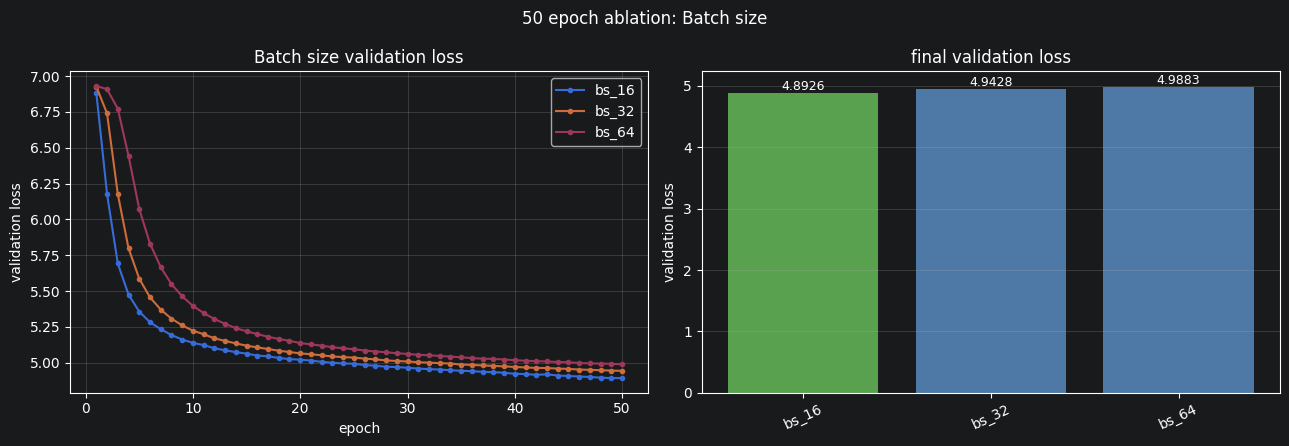

saved: figures\ablation50_batch_size.png


In [ ]:
# ABLATION50_BATCH_SIZE_PLOT
plot_ablation50("batch_size", "Batch size")


In [ ]:
22
